In [7]:
import uproot
import pandas as pd
import matplotlib.pyplot as plt

run_number = 51


chunks = []

with uproot.open(f"~/Scrivania/sampic_run{run_number}_merged.root") as file:
    tree = file["picoTree"]
    
    # Prima vediamo cosa c'è nel tree
    print("Branch disponibili:")
    print(tree.keys())
    print(f"\nNumero totale di eventi: {tree.num_entries}")

Branch disponibili:
['Detector', 'Feb', 'Multiplicity', 'Channel', 'Cell0TimeStamp', 'TimeInstant', 'TOTValue', 'PeakValue', 'Baseline', 'Waveform', 'Amplitude', 'ArraySize', 'xCoord', 'yCoord', 'Davide', 'Golia', '7PAD', 'MCP']

Numero totale di eventi: 638043


In [8]:
import uproot
import awkward as ak
import numpy as np
import pandas as pd

branch_list = [
    'Detector', 'Feb', 'Multiplicity', 'Channel',
    'Cell0TimeStamp', 'TimeInstant', 'TOTValue', 'PeakValue',
    'Baseline', 'Amplitude', 'ArraySize',
    'xCoord', 'yCoord', 'Davide', 'Golia', '7PAD', 'MCP'
]

branch_2d = [
    'Detector', 'Feb', 'Multiplicity', 'Channel',
    'Cell0TimeStamp', 'TimeInstant', 'TOTValue', 'PeakValue',
    'Baseline', 'Amplitude', 'xCoord', 'yCoord'
]

branch_1d = ['ArraySize', 'Davide', 'Golia', '7PAD', 'MCP']

chunks = []

with uproot.open(f"~/Scrivania/sampic_run{run_number}_merged.root") as file:
    tree = file["picoTree"]
    n_tot = tree.num_entries

    for i, chunk in enumerate(tree.iterate(branch_list, library="ak", step_size=50_000)):
        n_chunk = len(chunk)

        # ArraySize dice esattamente quante hit valide ci sono per evento
        array_size = ak.to_numpy(chunk['ArraySize'])  # shape (n_chunk,)

        # --- Branch 2D: taglia ogni riga a ArraySize invece di usare maschera -1 ---
        arr_2d = {k: ak.to_numpy(chunk[k]) for k in branch_2d}

        rows_2d = {k: [] for k in branch_2d}
        for evt in range(n_chunk):
            n_hit = array_size[evt]
            for k in branch_2d:
                rows_2d[k].append(arr_2d[k][evt, :n_hit])

        df_2d = pd.DataFrame({k: np.concatenate(rows_2d[k]) for k in branch_2d})

        # --- Branch 1D: ripeti per ogni hit dell'evento ---
        arr_1d = {k: ak.to_numpy(chunk[k]) for k in branch_1d}
        df_1d = pd.DataFrame({k: np.repeat(arr_1d[k], array_size) for k in branch_1d})

        # --- Multiplicity: estrai le 3 posizioni come colonne separate ---
        mult = ak.to_numpy(chunk['Multiplicity'])  # shape (n_chunk, 140)
        df_mult_per_evento = pd.DataFrame({
            'Mult_det0': mult[:, 0],
            'Mult_det1': mult[:, 1],
            'Mult_det2': mult[:, 2],
        })
        # Ripeti per ogni hit dell'evento
        df_mult = pd.DataFrame({
            col: np.repeat(df_mult_per_evento[col].values, array_size)
            for col in df_mult_per_evento.columns
        })

        # --- Indice evento ---
        event_idx = np.repeat(np.arange(i * 50_000, i * 50_000 + n_chunk), array_size)

        # --- Assembla ---
        df_chunk = pd.concat([
            pd.Series(event_idx, name='event_idx'),
            df_2d.reset_index(drop=True),
            df_1d.reset_index(drop=True),
            df_mult.reset_index(drop=True)
        ], axis=1)

        # Rimuovi Multiplicity grezza (era 2D, ora abbiamo le 3 colonne separate)
        df_chunk.drop(columns=['Multiplicity'], inplace=True)

        chunks.append(df_chunk)
        print(f"Chunk {i+1} — eventi: {n_chunk} — hit totali: {len(df_chunk)} — letti: {min((i+1)*50_000, n_tot)}/{n_tot}")

df = pd.concat(chunks, ignore_index=True)
print(f"\n✅ DataFrame finale: {df.shape}")
print(df.head(50))

Chunk 1 — eventi: 50000 — hit totali: 93499 — letti: 50000/638043
Chunk 2 — eventi: 50000 — hit totali: 72236 — letti: 100000/638043
Chunk 3 — eventi: 50000 — hit totali: 68193 — letti: 150000/638043
Chunk 4 — eventi: 50000 — hit totali: 75496 — letti: 200000/638043
Chunk 5 — eventi: 50000 — hit totali: 75299 — letti: 250000/638043
Chunk 6 — eventi: 50000 — hit totali: 66798 — letti: 300000/638043
Chunk 7 — eventi: 50000 — hit totali: 74427 — letti: 350000/638043
Chunk 8 — eventi: 50000 — hit totali: 67345 — letti: 400000/638043
Chunk 9 — eventi: 50000 — hit totali: 74660 — letti: 450000/638043
Chunk 10 — eventi: 50000 — hit totali: 74350 — letti: 500000/638043
Chunk 11 — eventi: 50000 — hit totali: 67146 — letti: 550000/638043
Chunk 12 — eventi: 50000 — hit totali: 67966 — letti: 600000/638043
Chunk 13 — eventi: 38043 — hit totali: 54899 — letti: 638043/638043

✅ DataFrame finale: (932314, 20)
    event_idx  Detector  Feb  Channel  Cell0TimeStamp   TimeInstant  TOTValue  \
0          

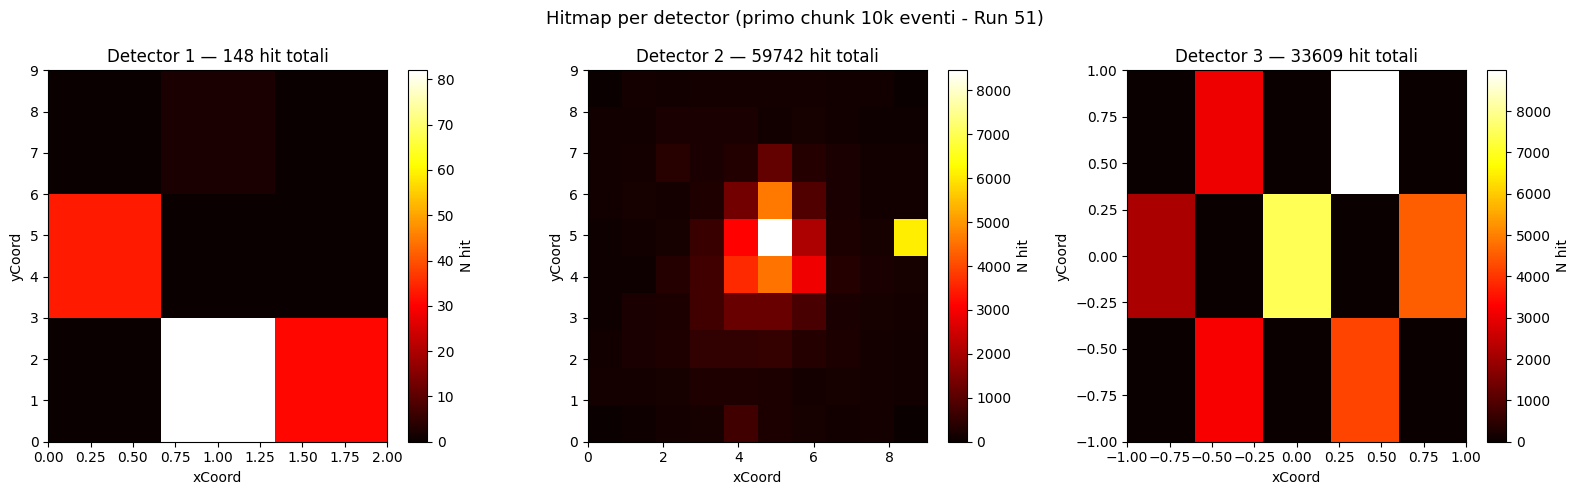

In [9]:
#hitmap
with uproot.open(f"~/Scrivania/sampic_run{run_number}_merged.root") as file:
    tree = file["picoTree"]
    
    # Leggi un chunk piccolo per la hitmap
    chunk = next(iter(tree.iterate(
        ['Detector', 'Channel', 'Multiplicity', 'ArraySize', 'xCoord', 'yCoord'], 
        library="ak", step_size=50000
    )))
    
    det        = ak.to_numpy(chunk['Detector'])
    mult       = ak.to_numpy(chunk['Multiplicity'])
    array_size = ak.to_numpy(chunk['ArraySize'])
    xcoord     = ak.to_numpy(chunk['xCoord'])
    ycoord     = ak.to_numpy(chunk['yCoord'])

    # --- Hitmap per detector ---
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    for i, det_id in enumerate([1, 2, 3]):
        # Conta hit per coordinata (x, y) filtrando per detector
        x_hits = []
        y_hits = []

        for evt in range(len(array_size)):
            n_hit = array_size[evt]
            for hit in range(n_hit):
                if det[evt, hit] == det_id:
                    x_hits.append(xcoord[evt, hit])
                    y_hits.append(ycoord[evt, hit])

        if len(x_hits) == 0:
            axes[i].set_title(f"Detector {det_id} — nessuna hit")
            axes[i].axis('off')
            continue

        x_hits = np.array(x_hits)
        y_hits = np.array(y_hits)

        # Valori unici di coordinate
        x_unique = np.sort(np.unique(x_hits))
        y_unique = np.sort(np.unique(y_hits))

        # Costruisci la mappa 2D
        hitmap = np.zeros((len(y_unique), len(x_unique)))
        for x, y in zip(x_hits, y_hits):
            ix = np.where(x_unique == x)[0][0]
            iy = np.where(y_unique == y)[0][0]
            hitmap[iy, ix] += 1

        im = axes[i].imshow(
            hitmap, origin='lower', aspect='auto',
            extent=[x_unique[0], x_unique[-1], y_unique[0], y_unique[-1]],
            cmap='hot'
        )
        plt.colorbar(im, ax=axes[i], label='N hit')
        axes[i].set_xlabel("xCoord")
        axes[i].set_ylabel("yCoord")
        axes[i].set_title(f"Detector {det_id} — {len(x_hits)} hit totali")

    plt.suptitle(f"Hitmap per detector (primo chunk 10k eventi - Run {run_number})", fontsize=13)
    plt.tight_layout()
    plt.show()

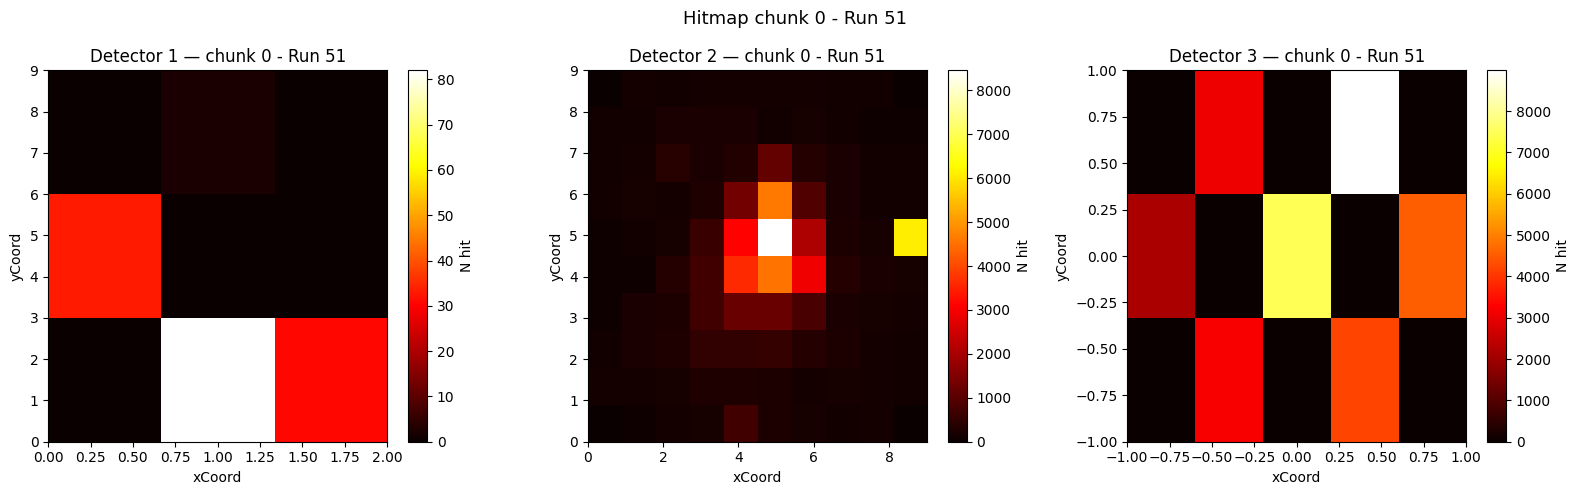

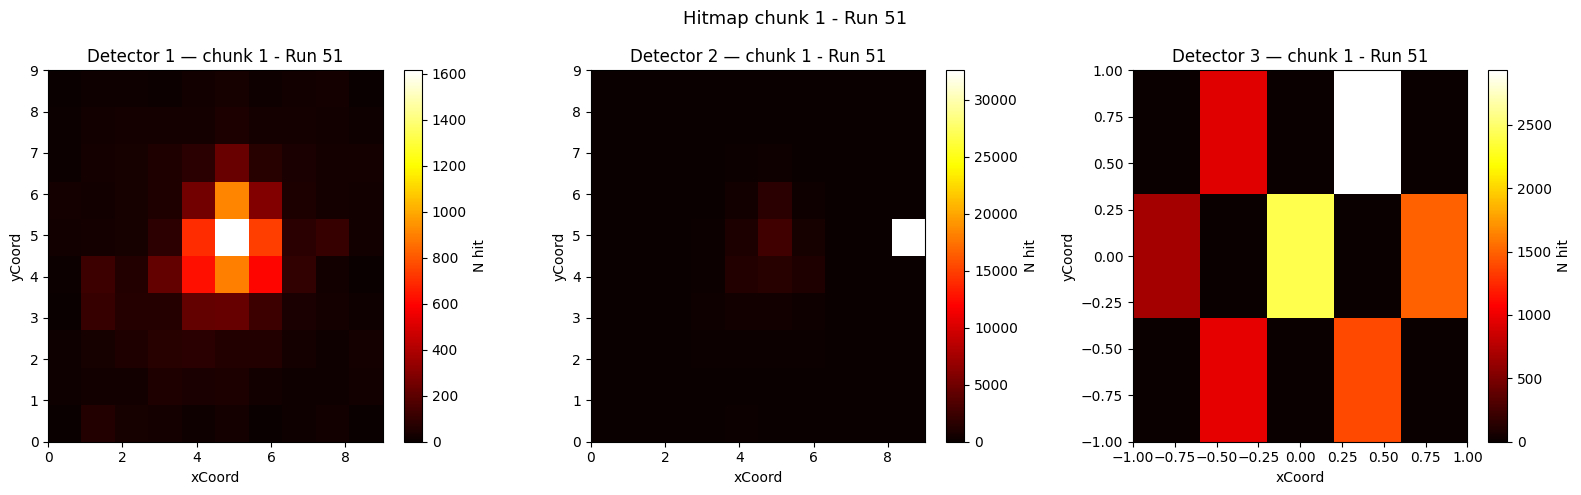

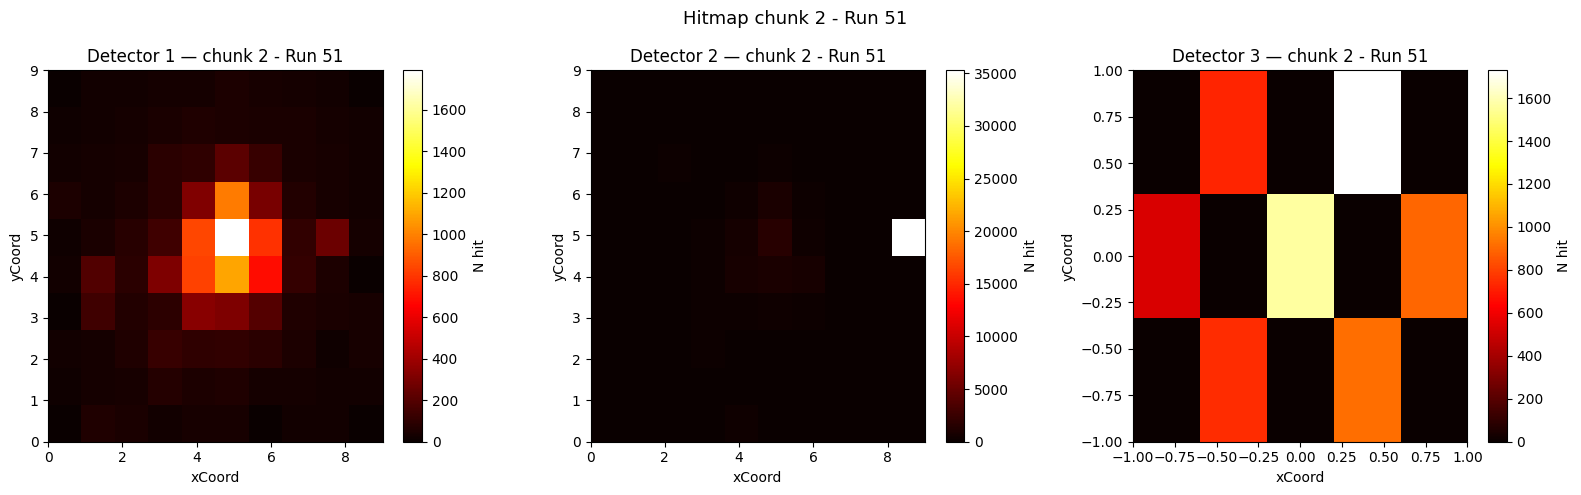

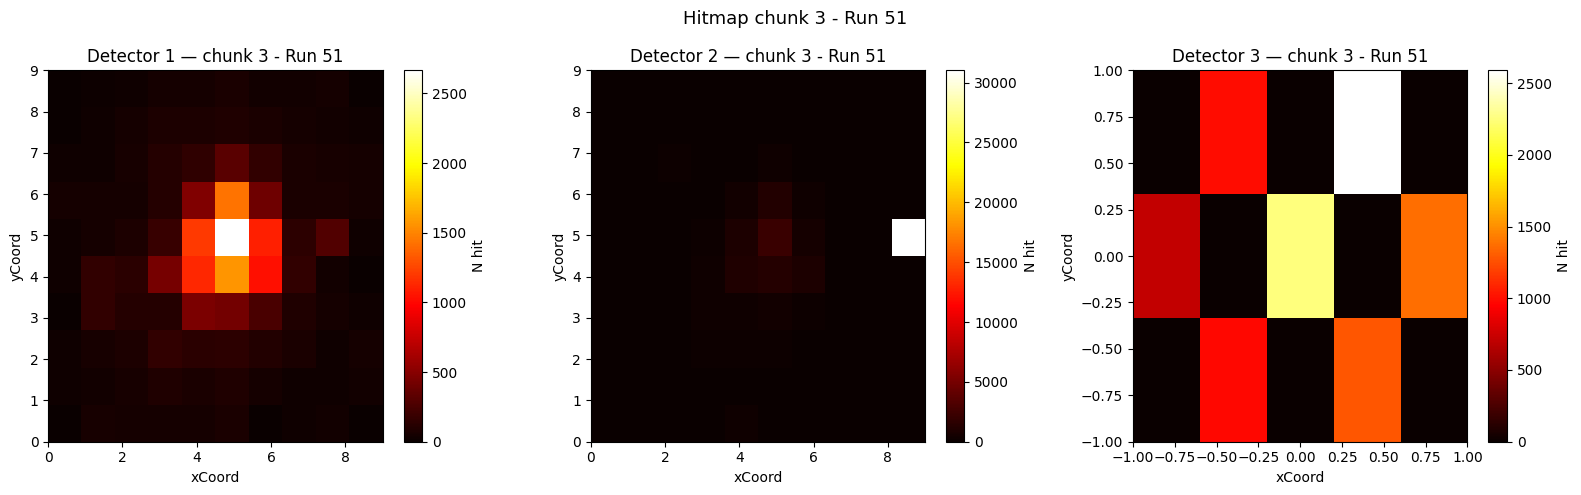

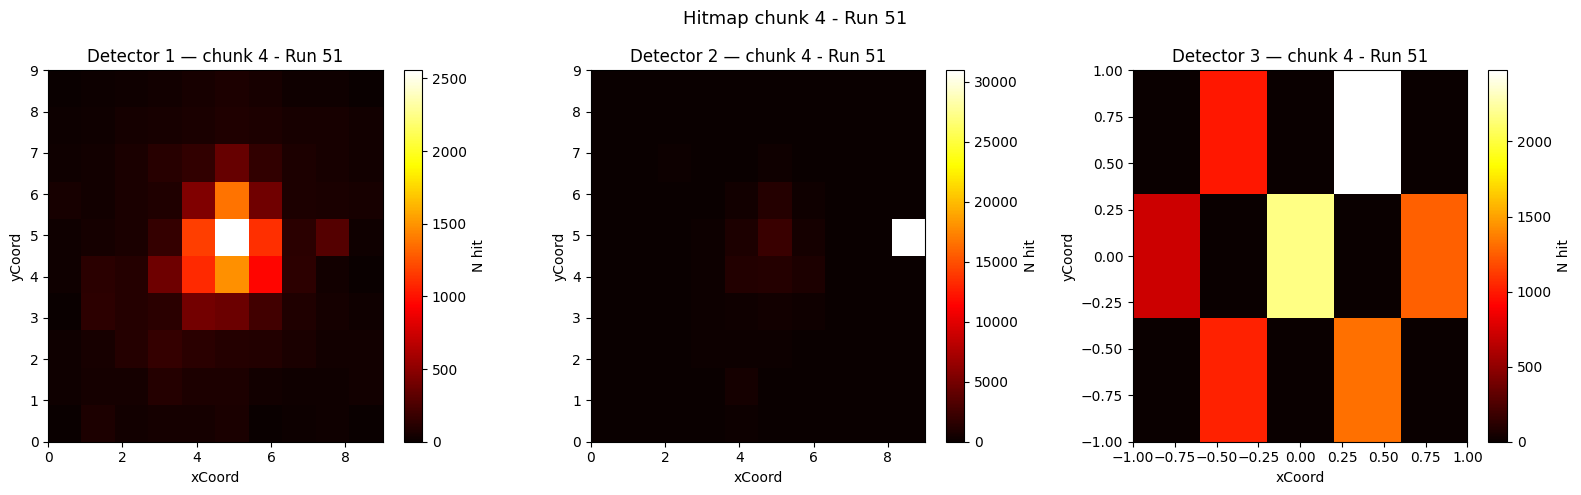

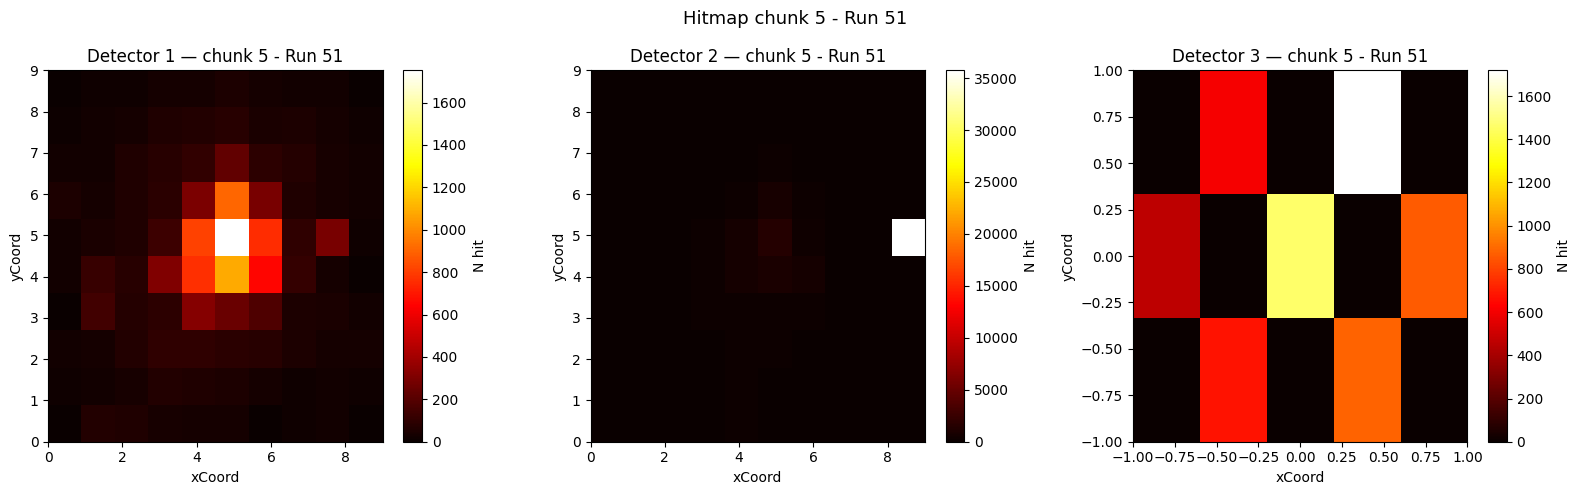

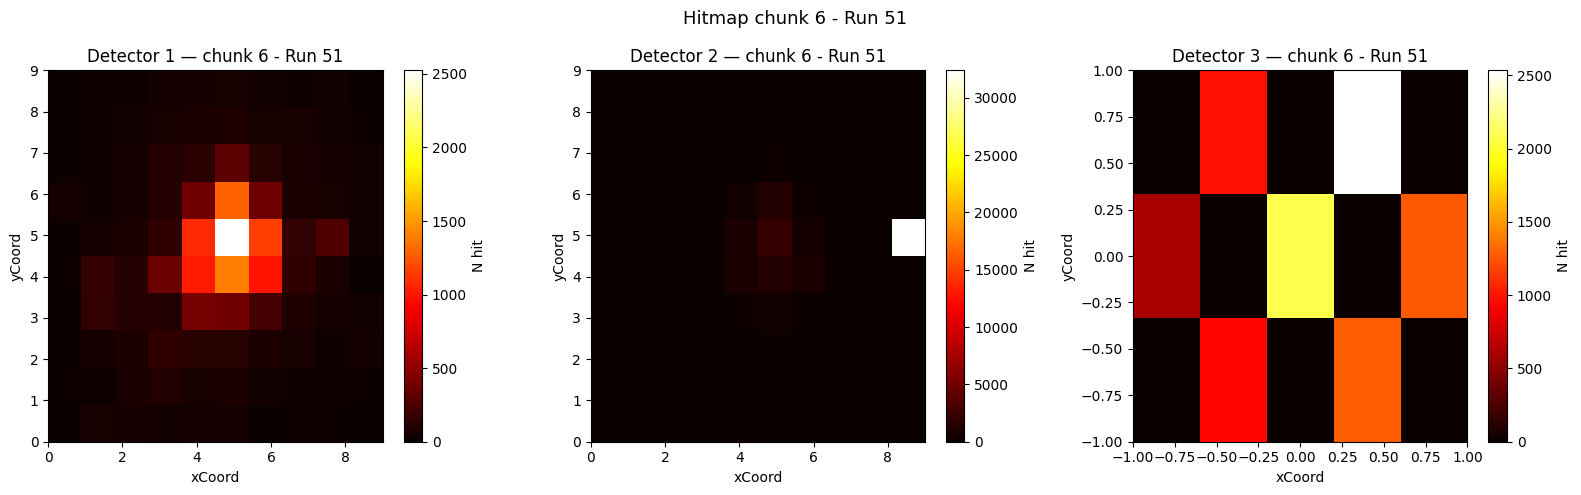

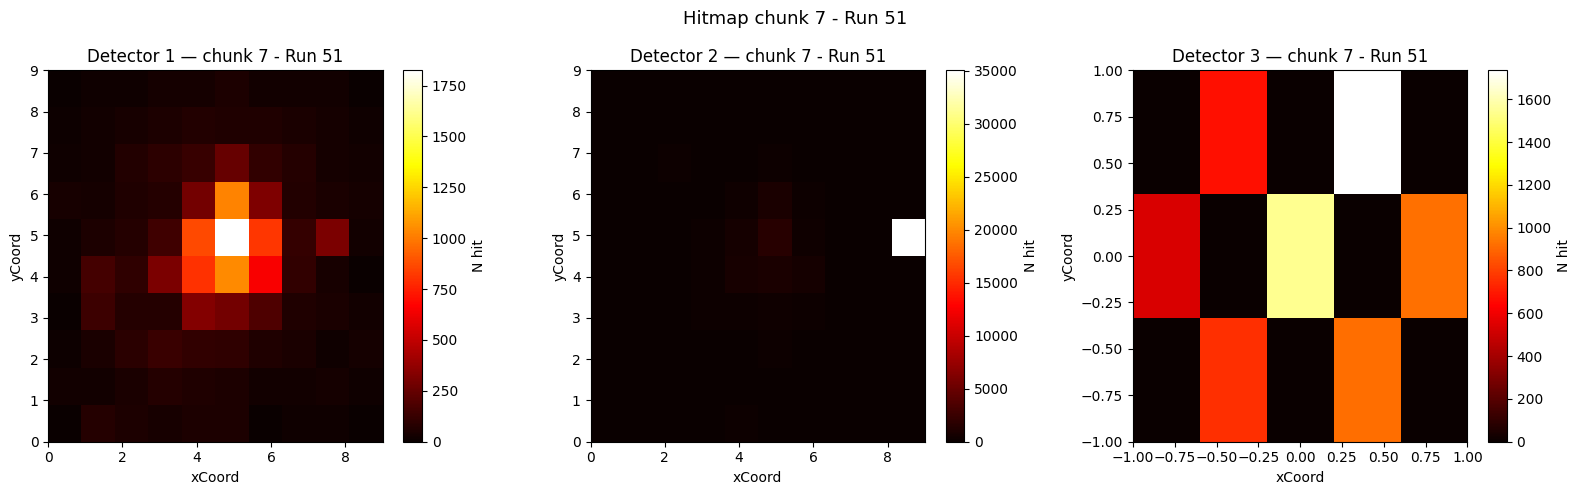

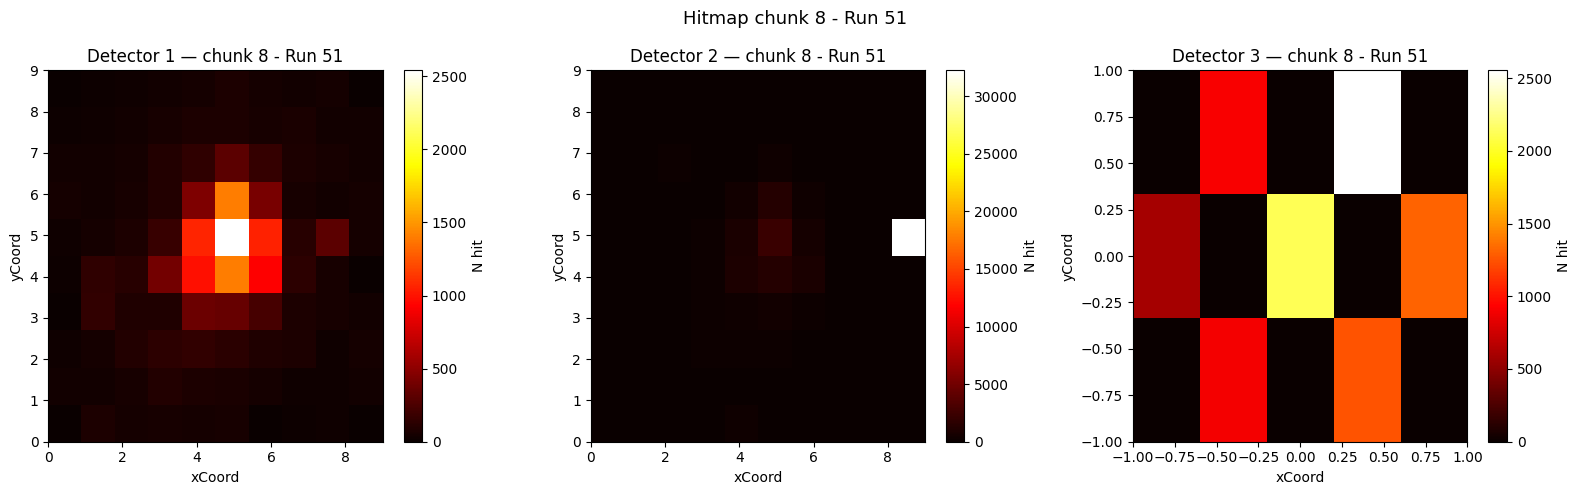

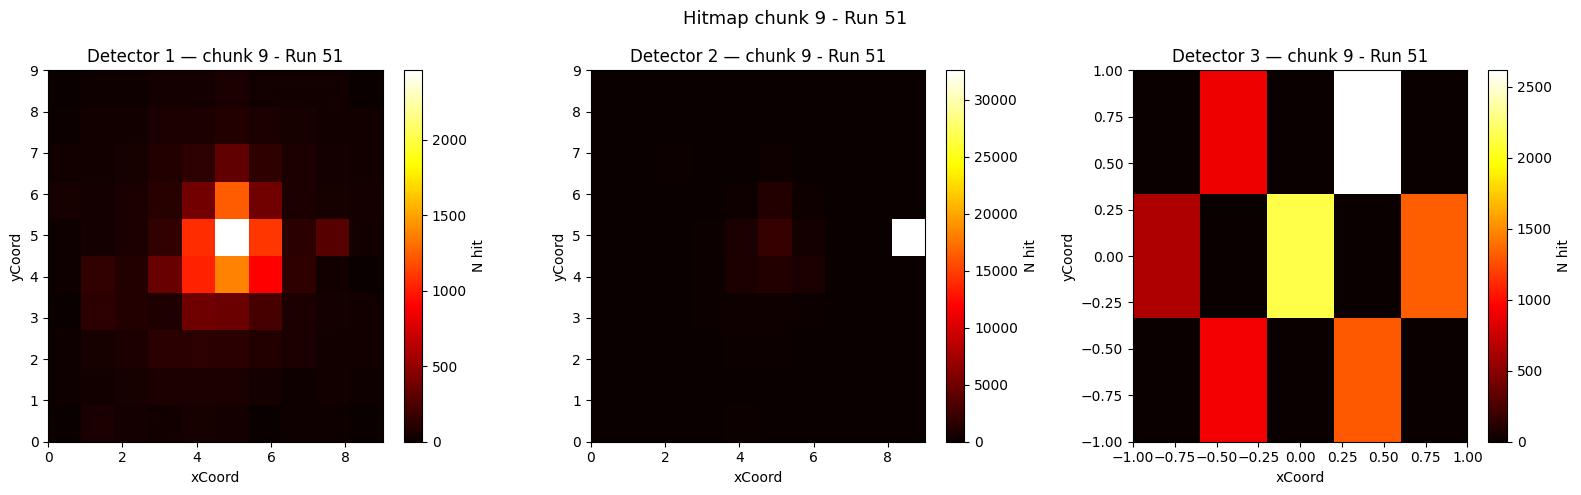

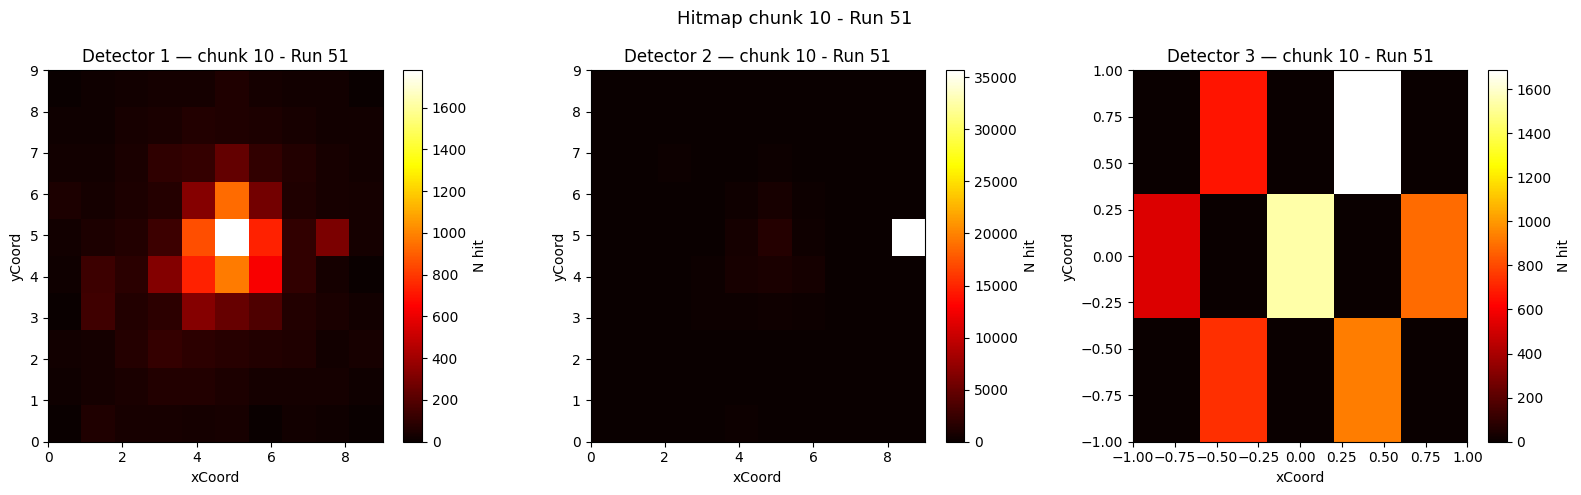

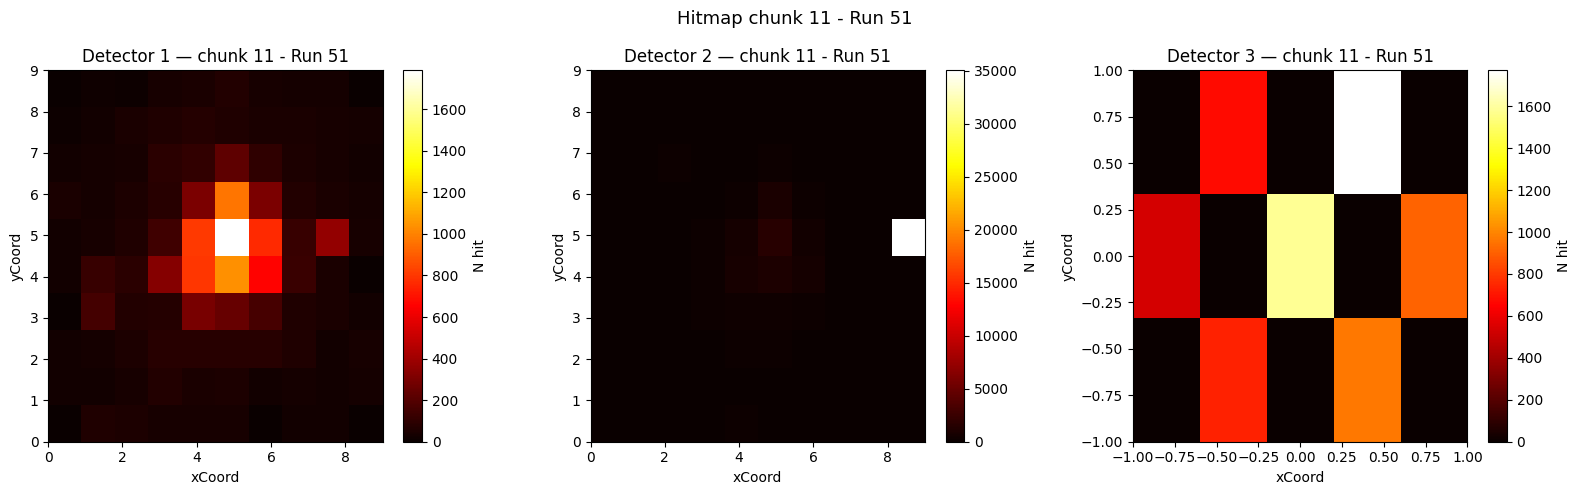

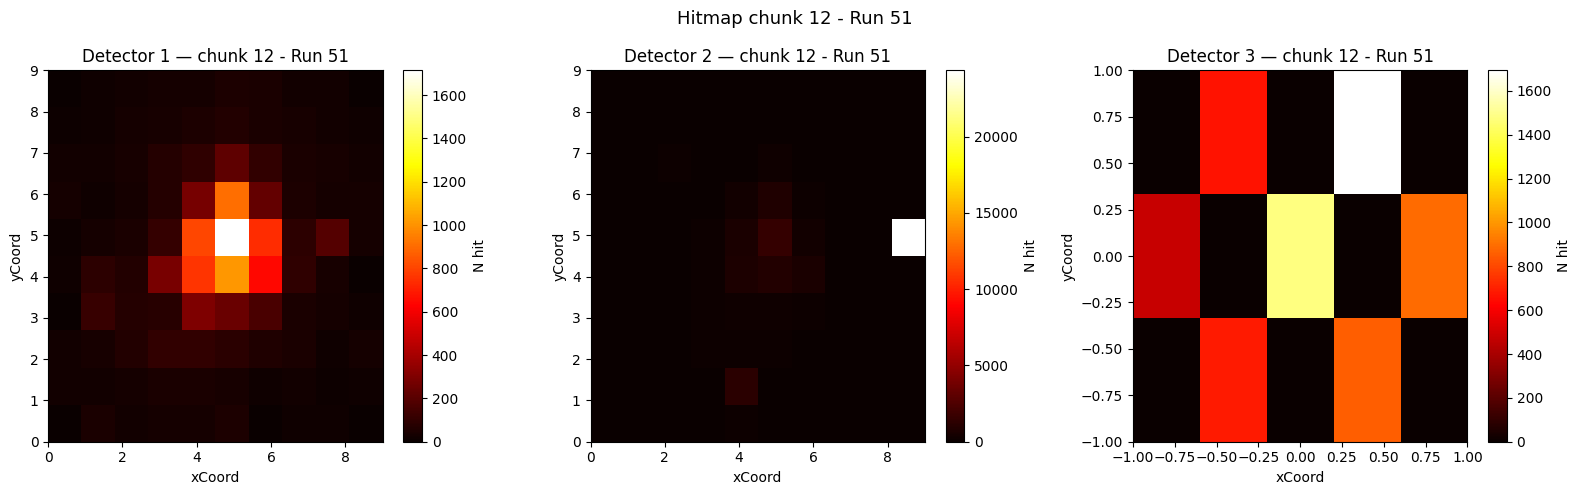

In [10]:
#hitmap per ogni chunk

with uproot.open(f"~/Scrivania/sampic_run{run_number}_merged.root") as file:
    tree = file["picoTree"]

    # Loop su tutti i chunk
    for chunk_id, chunk in enumerate(tree.iterate(
        ['Detector', 'Channel', 'Multiplicity', 'ArraySize', 'xCoord', 'yCoord'],
        library="ak",
        step_size=50000
    )):

        det        = ak.to_numpy(chunk['Detector'])
        mult       = ak.to_numpy(chunk['Multiplicity'])
        array_size = ak.to_numpy(chunk['ArraySize'])
        xcoord     = ak.to_numpy(chunk['xCoord'])
        ycoord     = ak.to_numpy(chunk['yCoord'])

        # --- Hitmap per detector ---
        fig, axes = plt.subplots(1, 3, figsize=(16, 5))

        for i, det_id in enumerate([1, 2, 3]):

            x_hits = []
            y_hits = []

            for evt in range(len(array_size)):
                n_hit = array_size[evt]

                for hit in range(n_hit):

                    if det[evt, hit] == det_id:
                        x_hits.append(xcoord[evt, hit])
                        y_hits.append(ycoord[evt, hit])

            if len(x_hits) == 0:
                axes[i].set_title(f"Detector {det_id} — nessuna hit")
                axes[i].axis('off')
                continue

            x_hits = np.array(x_hits)
            y_hits = np.array(y_hits)

            # Valori unici coordinate
            x_unique = np.sort(np.unique(x_hits))
            y_unique = np.sort(np.unique(y_hits))

            # Costruisci hitmap
            hitmap = np.zeros((len(y_unique), len(x_unique)))

            for x, y in zip(x_hits, y_hits):
                ix = np.where(x_unique == x)[0][0]
                iy = np.where(y_unique == y)[0][0]
                hitmap[iy, ix] += 1

            im = axes[i].imshow(
                hitmap,
                origin='lower',
                aspect='auto',
                extent=[
                    x_unique[0], x_unique[-1],
                    y_unique[0], y_unique[-1]
                ],
                cmap='hot'
            )

            plt.colorbar(im, ax=axes[i], label='N hit')

            axes[i].set_xlabel("xCoord")
            axes[i].set_ylabel("yCoord")
            axes[i].set_title(
                f"Detector {det_id} — chunk {chunk_id} - Run {run_number}"
            )

        plt.suptitle(f"Hitmap chunk {chunk_id} - Run {run_number}", fontsize=13)
        plt.tight_layout()
        plt.show()

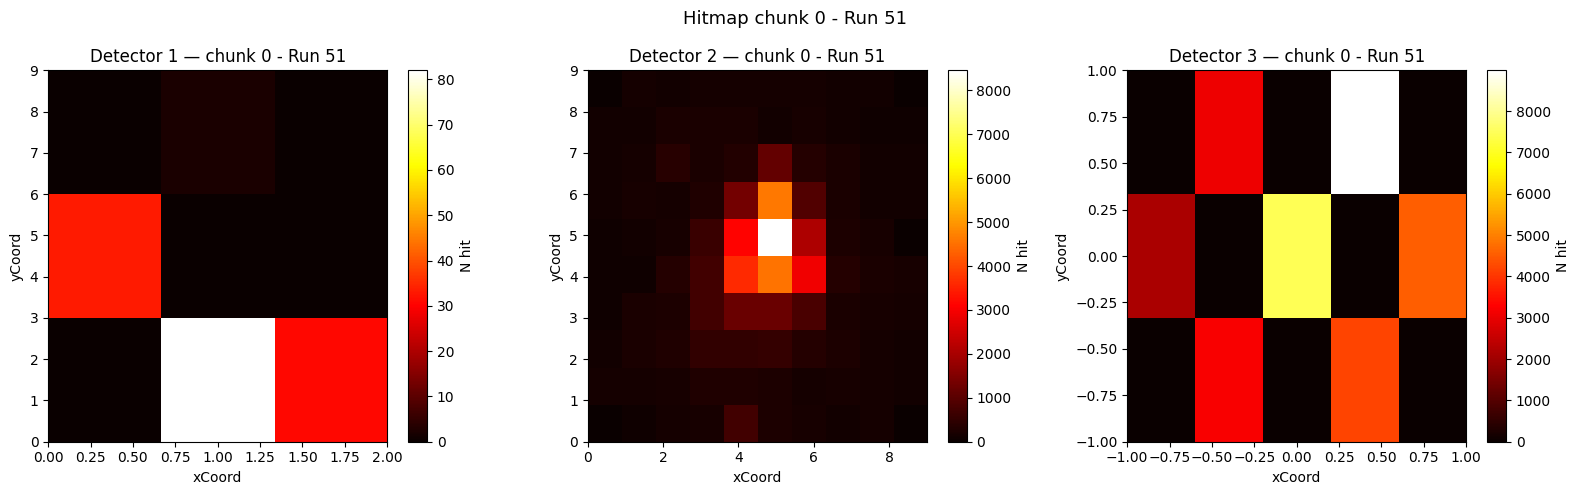

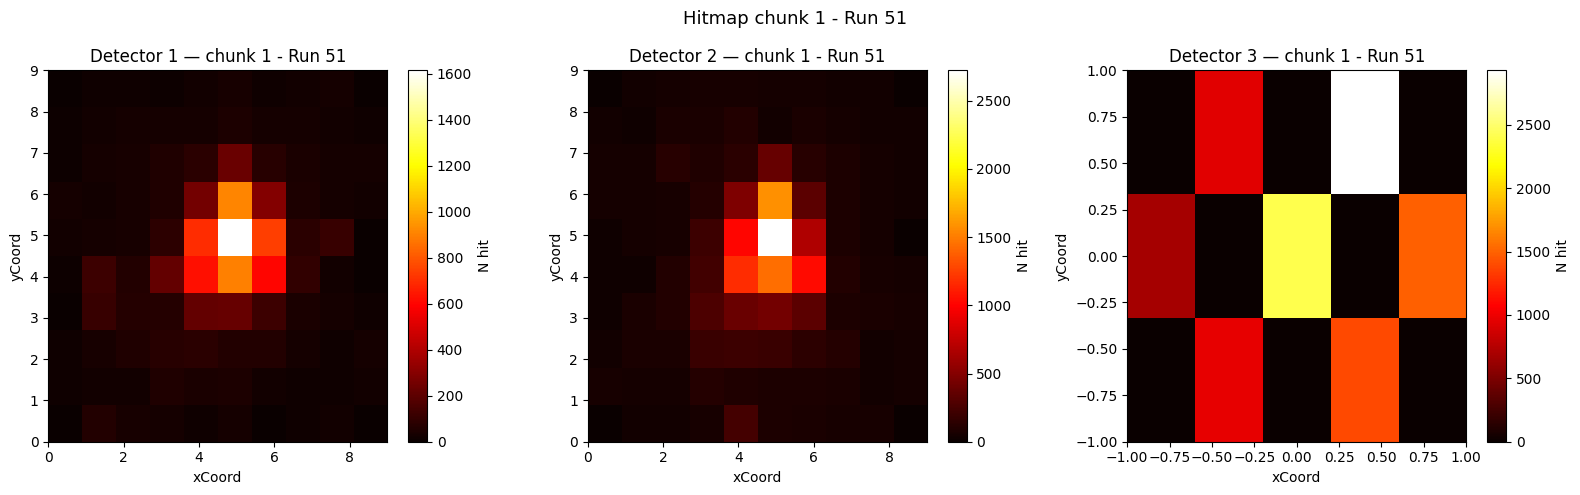

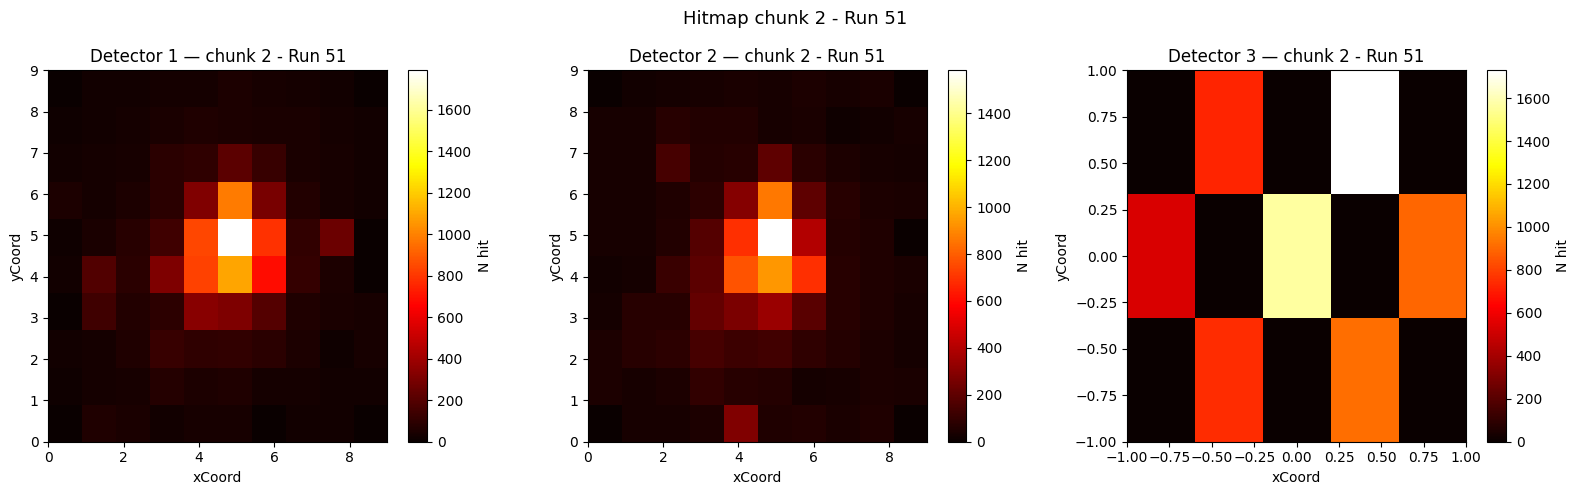

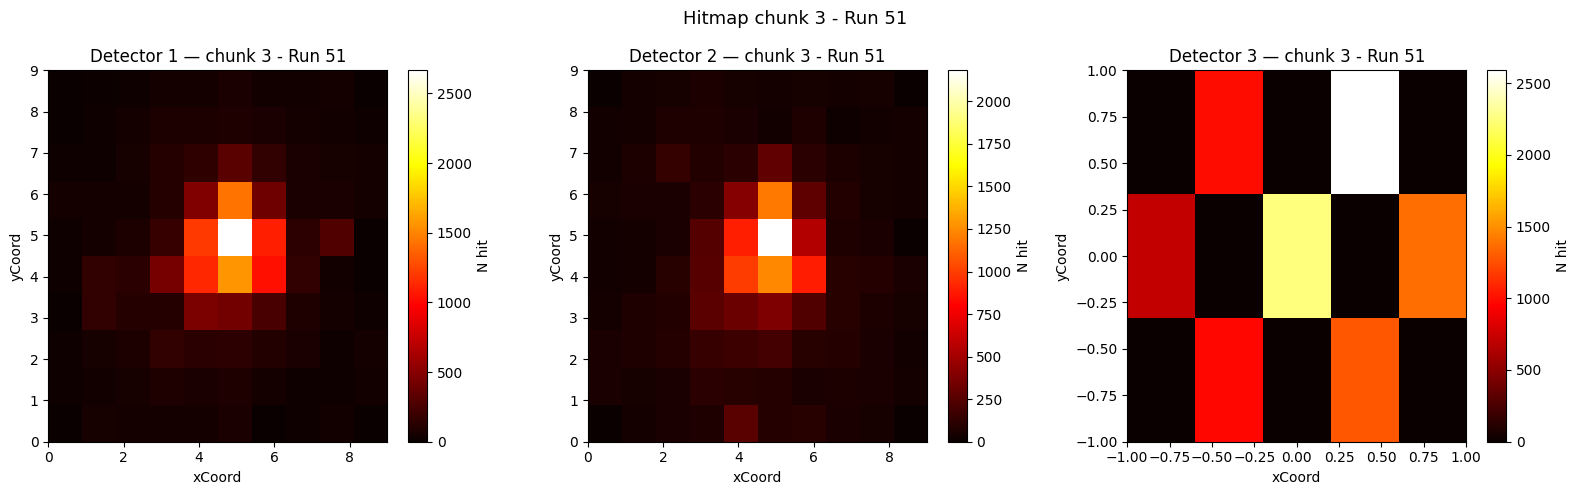

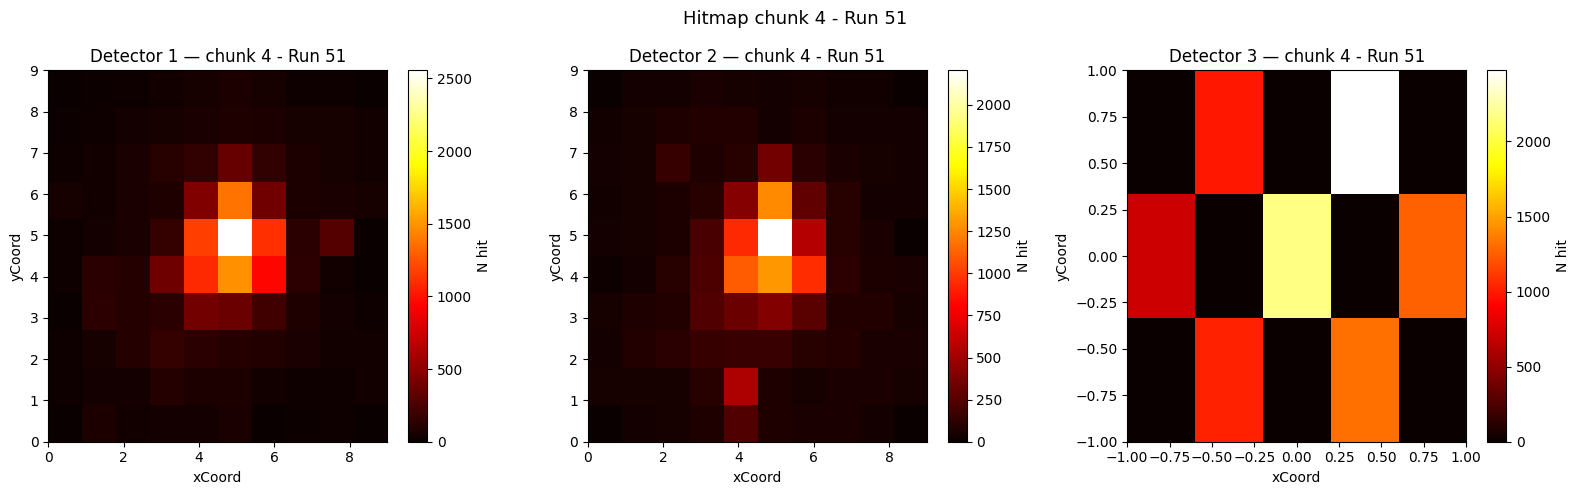

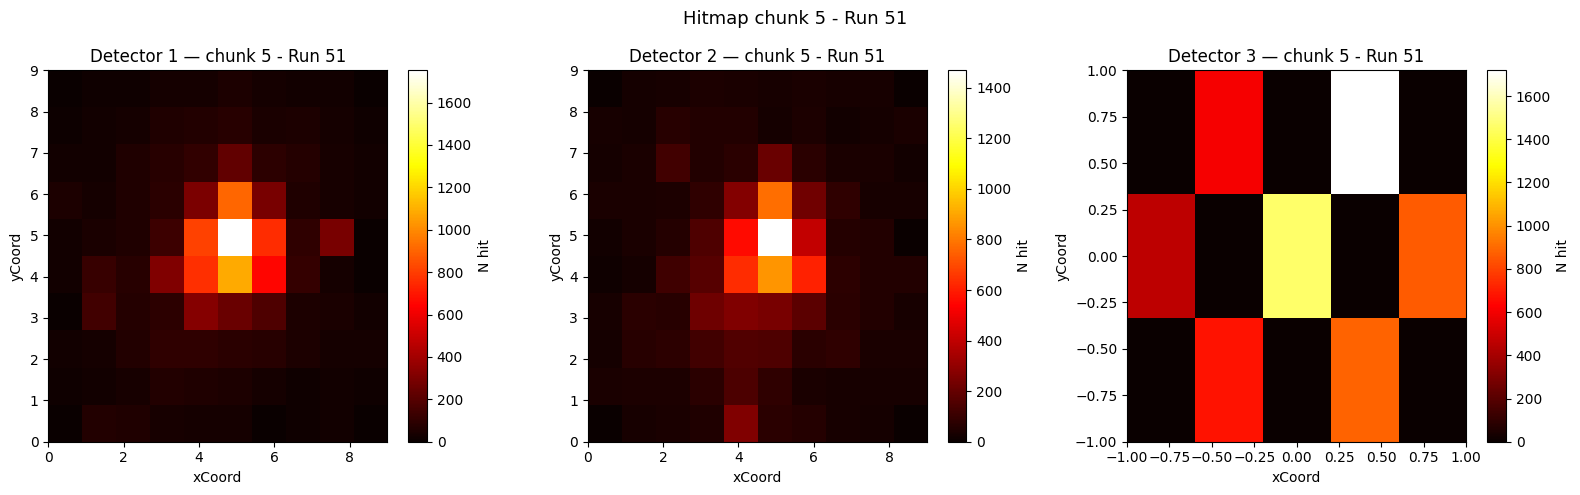

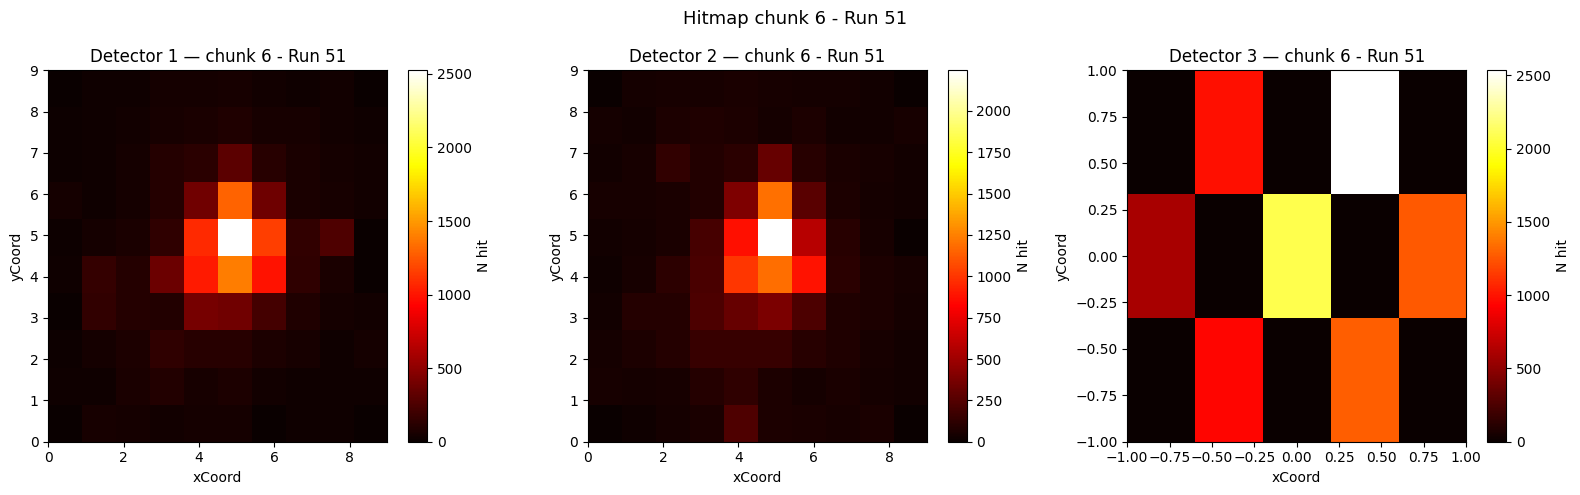

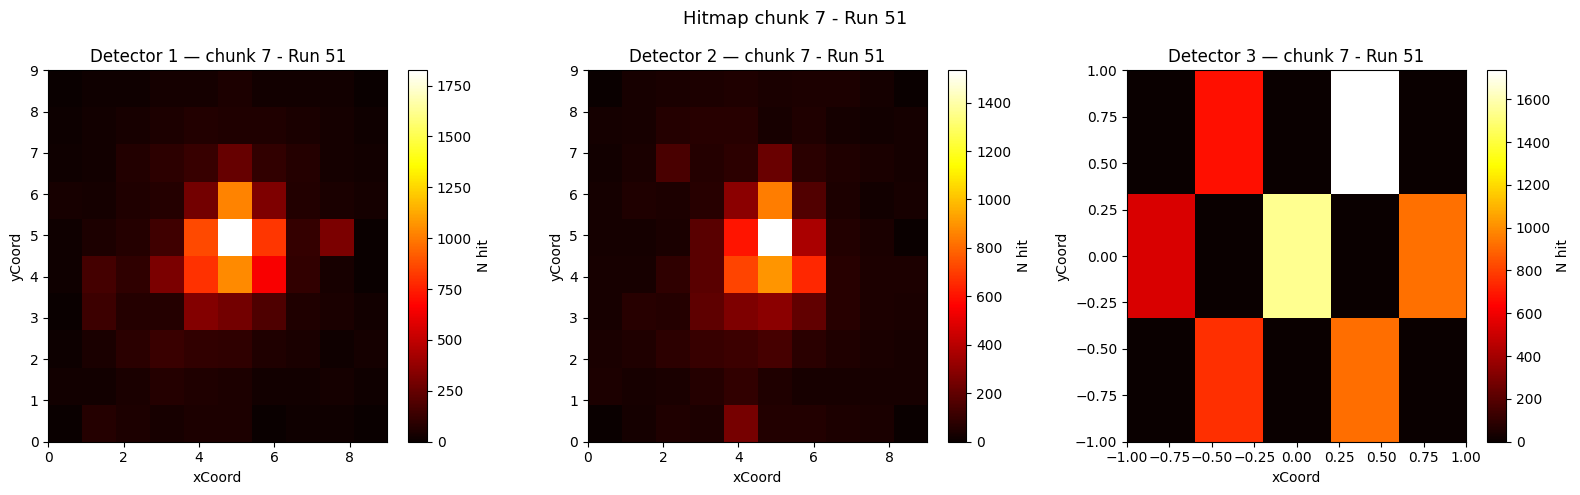

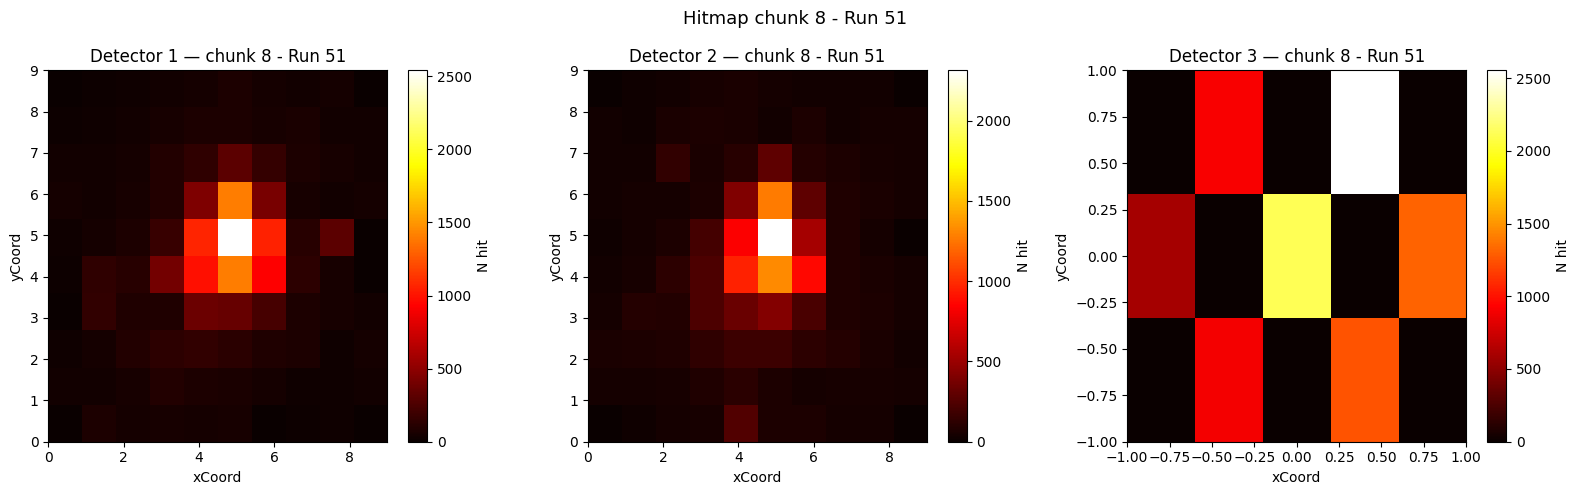

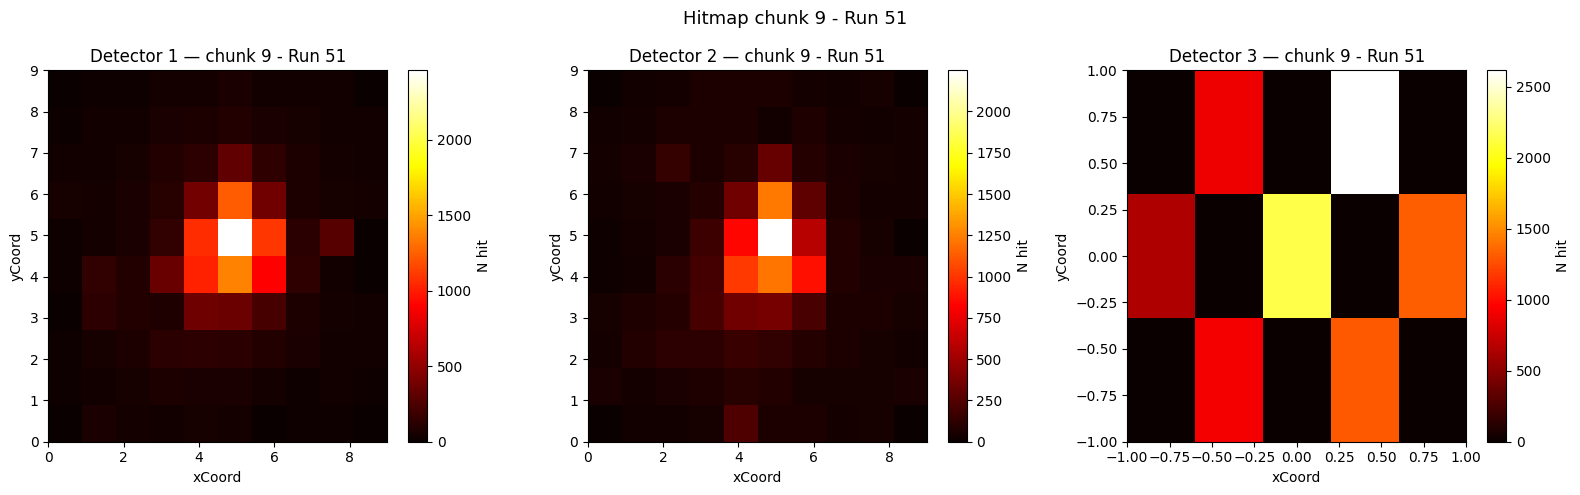

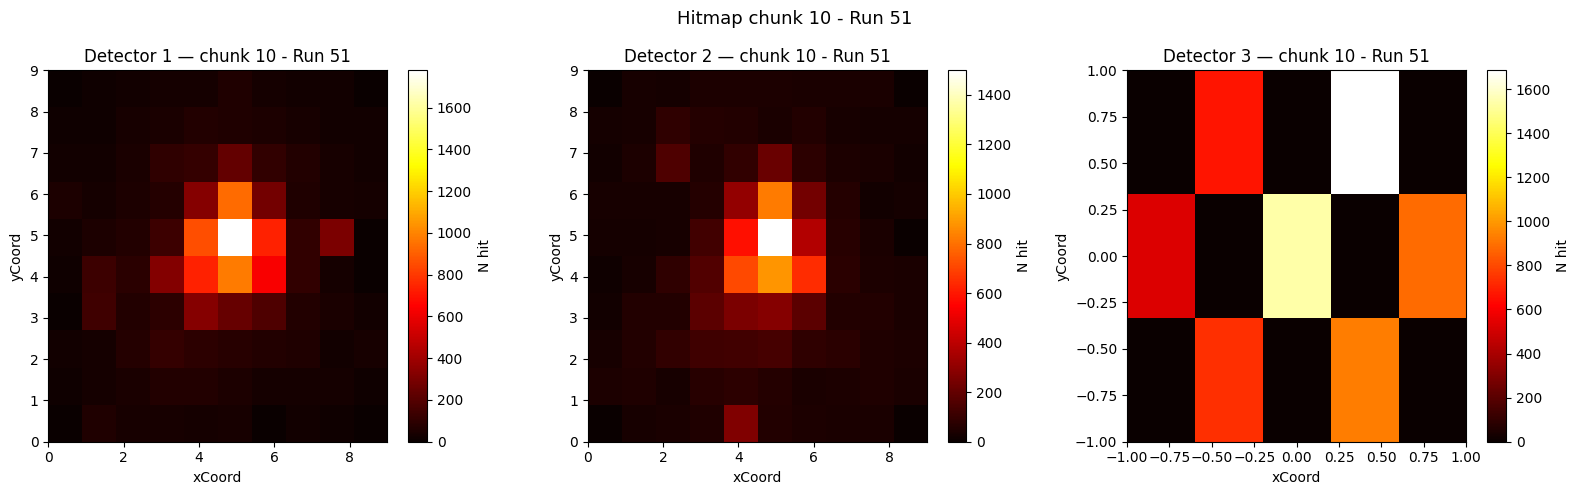

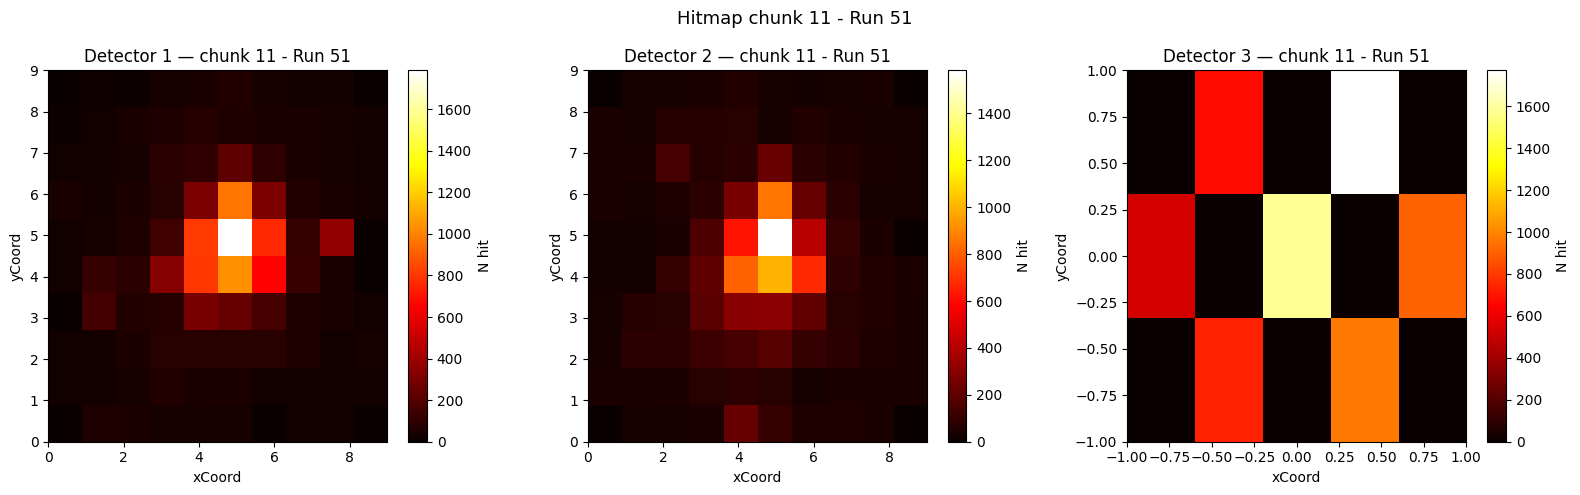

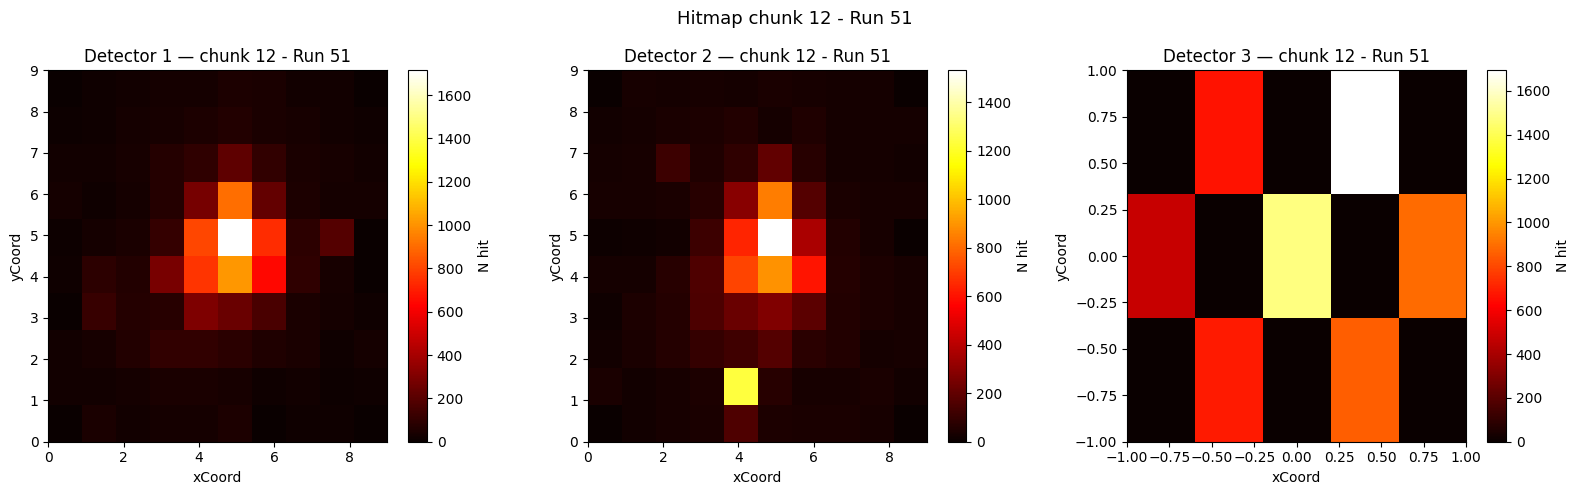

In [11]:
with uproot.open(f"~/Scrivania/sampic_run{run_number}_merged.root") as file:
    tree = file["picoTree"]

    # Loop su tutti i chunk
    for chunk_id, chunk in enumerate(tree.iterate(
        ['Detector', 'Channel', 'Multiplicity', 'ArraySize', 'xCoord', 'yCoord'],
        library="ak",
        step_size=50000
    )):

        det        = ak.to_numpy(chunk['Detector'])
        mult       = ak.to_numpy(chunk['Multiplicity'])
        array_size = ak.to_numpy(chunk['ArraySize'])
        xcoord     = ak.to_numpy(chunk['xCoord'])
        ycoord     = ak.to_numpy(chunk['yCoord'])

        # --- Hitmap per detector ---
        fig, axes = plt.subplots(1, 3, figsize=(16, 5))

        for i, det_id in enumerate([1, 2, 3]):

            x_hits = []
            y_hits = []

            for evt in range(len(array_size)):
                n_hit = array_size[evt]

                for hit in range(n_hit):

                    if det[evt, hit] == det_id:

                        # silenzia canale x=9, y=4
                        if xcoord[evt, hit] == 9 and ycoord[evt, hit] == 5:
                            continue

                        x_hits.append(xcoord[evt, hit])
                        y_hits.append(ycoord[evt, hit])

            if len(x_hits) == 0:
                axes[i].set_title(f"Detector {det_id} — nessuna hit")
                axes[i].axis('off')
                continue

            x_hits = np.array(x_hits)
            y_hits = np.array(y_hits)

            # Valori unici coordinate
            x_unique = np.sort(np.unique(x_hits))
            y_unique = np.sort(np.unique(y_hits))

            # Costruisci hitmap
            hitmap = np.zeros((len(y_unique), len(x_unique)))

            for x, y in zip(x_hits, y_hits):
                ix = np.where(x_unique == x)[0][0]
                iy = np.where(y_unique == y)[0][0]
                hitmap[iy, ix] += 1

            im = axes[i].imshow(
                hitmap,
                origin='lower',
                aspect='auto',
                extent=[
                    x_unique[0], x_unique[-1],
                    y_unique[0], y_unique[-1]
                ],
                cmap='hot'
            )

            plt.colorbar(im, ax=axes[i], label='N hit')

            axes[i].set_xlabel("xCoord")
            axes[i].set_ylabel("yCoord")
            axes[i].set_title(
                f"Detector {det_id} — chunk {chunk_id} - Run {run_number}"
            )

        plt.suptitle(f"Hitmap chunk {chunk_id} - Run {run_number}", fontsize=13)
        plt.tight_layout()
        plt.show()

Chunk 1 — letti 50000/638043 eventi
Chunk 2 — letti 100000/638043 eventi
Chunk 3 — letti 150000/638043 eventi
Chunk 4 — letti 200000/638043 eventi
Chunk 5 — letti 250000/638043 eventi
Chunk 6 — letti 300000/638043 eventi
Chunk 7 — letti 350000/638043 eventi
Chunk 8 — letti 400000/638043 eventi
Chunk 9 — letti 450000/638043 eventi
Chunk 10 — letti 500000/638043 eventi
Chunk 11 — letti 550000/638043 eventi
Chunk 12 — letti 600000/638043 eventi
Chunk 13 — letti 638043/638043 eventi


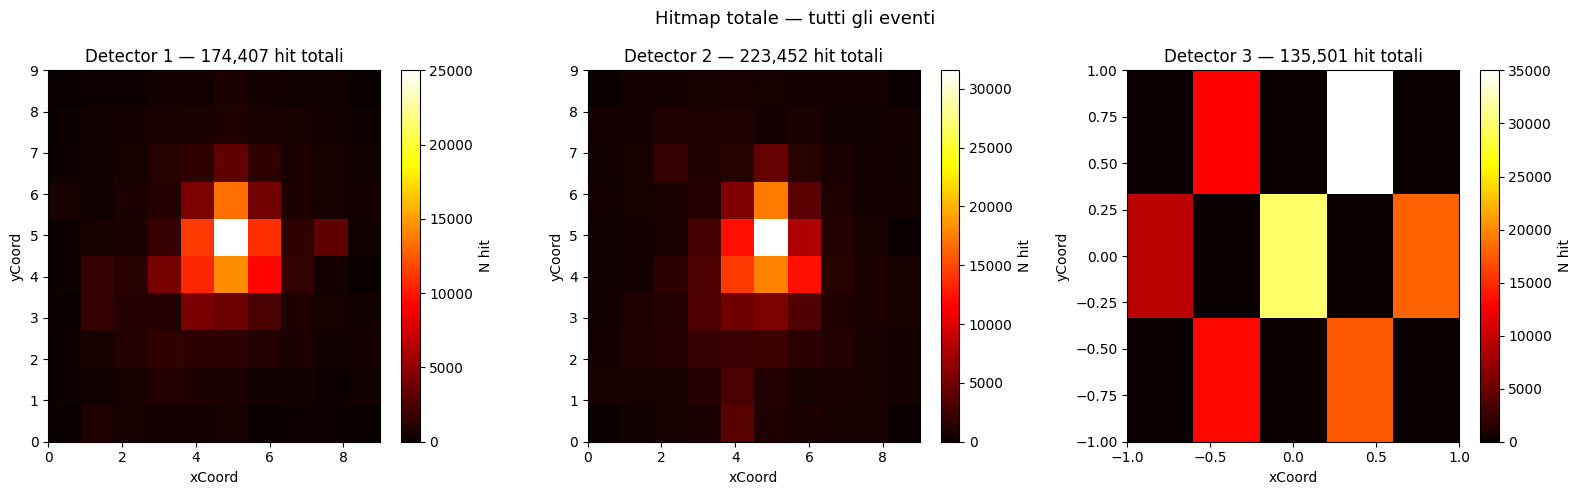

In [13]:
import uproot
import awkward as ak
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

# Accumula hit per ogni detector
hits = {1: {'x': [], 'y': []}, 
        2: {'x': [], 'y': []}, 
        3: {'x': [], 'y': []}}

with uproot.open(f"~/Scrivania/sampic_run{run_number}_merged.root") as file:
    tree = file["picoTree"] 

    n_tot = tree.num_entries

    for i, chunk in enumerate(tree.iterate(
        ['Detector', 'ArraySize', 'xCoord', 'yCoord'],
        library="ak", step_size=50_000
    )):
        det        = ak.to_numpy(chunk['Detector'])
        array_size = ak.to_numpy(chunk['ArraySize'])
        xcoord     = ak.to_numpy(chunk['xCoord'])
        ycoord     = ak.to_numpy(chunk['yCoord'])

        for evt in range(len(array_size)):
            n_hit = array_size[evt]
            for hit in range(n_hit):
                det_id = int(det[evt, hit])
                if det_id in hits:
                    hits[det_id]['x'].append(xcoord[evt, hit])
                    hits[det_id]['y'].append(ycoord[evt, hit])

        print(f"Chunk {i+1} — letti {min((i+1)*50_000, n_tot)}/{n_tot} eventi")

# --- Hitmap ---
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, det_id in enumerate([1, 2, 3]):
    if(det_id == 2):
        # silenzia canale x=9, y=5
        mask = ~((np.array(hits[det_id]['x']) == 9) & (np.array(hits[det_id]['y']) == 5))
        hits[det_id]['x'] = np.array(hits[det_id]['x'])[mask]
        hits[det_id]['y'] = np.array(hits[det_id]['y'])[mask]
    x = np.array(hits[det_id]['x'])
    y = np.array(hits[det_id]['y'])

    if len(x) == 0:
        axes[i].set_title(f"Detector {det_id} — nessuna hit")
        axes[i].axis('off')
        continue

    x_unique = np.sort(np.unique(x))
    y_unique = np.sort(np.unique(y))

    hitmap = np.zeros((len(y_unique), len(x_unique)))
    for xi, yi in zip(x, y):
        ix = np.where(x_unique == xi)[0][0]
        iy = np.where(y_unique == yi)[0][0]
        hitmap[iy, ix] += 1

    im = axes[i].imshow(
        hitmap, origin='lower', aspect='auto',
        extent=[x_unique[0], x_unique[-1], y_unique[0], y_unique[-1]],
        cmap='hot'
    )
    plt.colorbar(im, ax=axes[i], label='N hit')
    axes[i].set_xlabel("xCoord")
    axes[i].set_ylabel("yCoord")
    axes[i].set_title(f"Detector {det_id} — {len(x):,} hit totali")

plt.suptitle("Hitmap totale — tutti gli eventi", fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
import uproot
import awkward as ak
import numpy as np
import pandas as pd

# --- Parametri modificabili ---
X_TARGET = 5.0
Y_TARGET = 5.0

# Molteplicità per ogni detector — cambia solo questi!
MULT_DET0 = 0   # minimo hit detector 0
MULT_DET1 = 1   # minimo hit detector 1
MULT_DET2 = 0   # detector 2: whatever (0 = nessun vincolo)

# ------------------------------

branch_list = [
    'Detector', 'Feb', 'Channel', 'Cell0TimeStamp', 'TimeInstant',
    'TOTValue', 'PeakValue', 'Baseline', 'Amplitude', 'Waveform',
    'ArraySize', 'xCoord', 'yCoord', 'Multiplicity',
    'Davide', 'Golia', '7PAD', 'MCP'
]

branch_2d = [
    'Detector', 'Feb', 'Channel', 'Cell0TimeStamp', 'TimeInstant',
    'TOTValue', 'PeakValue', 'Baseline', 'Amplitude',
    'xCoord', 'yCoord'
]

branch_1d = ['ArraySize', 'Davide', 'Golia', '7PAD', 'MCP']

chunks = []

with uproot.open(f"~/Scrivania/sampic_run{run_number}_merged.root") as file:
    tree = file["picoTree"]
    n_tot = tree.num_entries

    for i, chunk in enumerate(tree.iterate(branch_list, library="ak", step_size=5_000)):
        n_chunk = len(chunk)

        array_size = ak.to_numpy(chunk['ArraySize'])     # (n_chunk,)
        mult       = ak.to_numpy(chunk['Multiplicity'])  # (n_chunk, 140)

        # xCoord e yCoord sono uguali per tutte le hit dell'evento, prendi la prima
        xcoord = ak.to_numpy(chunk['xCoord'])[:, 0]
        ycoord = ak.to_numpy(chunk['yCoord'])[:, 0]

        # --- Filtro evento ---
        mask_evento = (
            ((xcoord == X_TARGET) & (ycoord == Y_TARGET))|((xcoord == 0.5) & (ycoord==1)) &
            (mult[:, 0] == MULT_DET0) &
            (mult[:, 1] == MULT_DET1) &
            (mult[:, 2] >= MULT_DET2)   # se MULT_DET2=0 è sempre True
        )

        #mask provvisoria
        mask_evento =((mult[:, 0] >= MULT_DET0) &
            (mult[:, 1] == MULT_DET1) &
            (mult[:, 2] >= MULT_DET2) )

        if mask_evento.sum() == 0:
            continue

        n_sel = mask_evento.sum()
        array_size_filt = array_size[mask_evento]
        mult_filt       = mult[mask_evento]

        # --- Branch 2D ---
        arr_2d = {k: ak.to_numpy(chunk[k])[mask_evento] for k in branch_2d}
        rows_2d = {k: [] for k in arr_2d}
        for evt in range(n_sel):
            n_hit = array_size_filt[evt]
            for k in arr_2d:
                rows_2d[k].append(arr_2d[k][evt, :n_hit])
        df_2d = pd.DataFrame({k: np.concatenate(rows_2d[k]) for k in arr_2d})

        # --- Waveform ---
        waveform_raw = ak.to_numpy(chunk['Waveform'])[mask_evento]
        waveforms = []
        for evt in range(n_sel):
            n_hit = array_size_filt[evt]
            for hit in range(n_hit):
                waveforms.append(waveform_raw[evt, hit, :])
        df_2d['Waveform'] = waveforms

        # --- Branch 1D ---
        arr_1d = {k: ak.to_numpy(chunk[k])[mask_evento] for k in branch_1d}
        df_1d = pd.DataFrame({k: np.repeat(arr_1d[k], array_size_filt) for k in branch_1d})

        # --- Multiplicity come colonne separate ---
        df_mult = pd.DataFrame({
            'Mult_det1': np.repeat(mult_filt[:, 0], array_size_filt),
            'Mult_det2': np.repeat(mult_filt[:, 1], array_size_filt),
            'Mult_det3': np.repeat(mult_filt[:, 2], array_size_filt),
        })

        # --- Indice evento originale ---
        idx_originali = np.where(mask_evento)[0] + i * 5_000
        event_idx = np.repeat(idx_originali, array_size_filt)

        df_chunk = pd.concat([
            pd.Series(event_idx, name='event_idx'),
            df_2d.reset_index(drop=True),
            df_1d.reset_index(drop=True),
            df_mult.reset_index(drop=True)
        ], axis=1)

        chunks.append(df_chunk)
        print(f"Chunk {i+1} — eventi selezionati: {n_sel} — hit totali: {len(df_chunk)}")

df = pd.concat(chunks, ignore_index=True)
print(f"\n✅ DataFrame finale: {df.shape}")
print(df.head(50))

Chunk 1 — eventi selezionati: 2863 — hit totali: 4988
Chunk 2 — eventi selezionati: 2861 — hit totali: 4493
Chunk 3 — eventi selezionati: 2826 — hit totali: 4260
Chunk 4 — eventi selezionati: 2851 — hit totali: 4286
Chunk 5 — eventi selezionati: 2700 — hit totali: 4267
Chunk 6 — eventi selezionati: 2952 — hit totali: 4908
Chunk 7 — eventi selezionati: 2899 — hit totali: 4502
Chunk 8 — eventi selezionati: 2671 — hit totali: 4084
Chunk 9 — eventi selezionati: 3497 — hit totali: 4645
Chunk 10 — eventi selezionati: 4770 — hit totali: 4776
Chunk 11 — eventi selezionati: 4813 — hit totali: 4819
Chunk 12 — eventi selezionati: 3826 — hit totali: 5121
Chunk 13 — eventi selezionati: 3790 — hit totali: 4455
Chunk 14 — eventi selezionati: 4576 — hit totali: 4576
Chunk 15 — eventi selezionati: 4461 — hit totali: 4588
Chunk 16 — eventi selezionati: 3344 — hit totali: 6475
Chunk 17 — eventi selezionati: 3951 — hit totali: 3951
Chunk 18 — eventi selezionati: 4519 — hit totali: 4519
Chunk 19 — eventi s

In [ ]:
#controllo mask
# Controlla la distribuzione reale delle multiplicity
print("Distribuzione Mult_det0:")
print(df['Mult_det1'].value_counts().sort_index())

print("\nDistribuzione Mult_det1:")
print(df['Mult_det2'].value_counts().sort_index())

print("\nDistribuzione Mult_det2:")
print(df['Mult_det3'].value_counts().sort_index())

print("\nValori unici di Detector:")
print(df['Detector'].value_counts())

Distribuzione Mult_det0:
Mult_det1
0      6059
1     26648
2     20455
3      6002
4      1921
5       675
6       369
7       268
8       164
9        92
10       59
11       37
13       15
15       15
16       16
20       20
57       57
72       72
Name: count, dtype: int64

Distribuzione Mult_det1:
Mult_det2
0      6347
1     36180
2     15509
3      3018
4       804
5       630
6       214
7        70
8        43
9        18
10       22
11       36
12       12
13       13
28       28
Name: count, dtype: int64

Distribuzione Mult_det2:
Mult_det3
0    17595
1    32991
2    10436
3     1780
4      133
5        9
Name: count, dtype: int64

Valori unici di Detector:
Detector
1.0    26625
2.0    22840
3.0    13479
Name: count, dtype: int64


In [ ]:
with uproot.open(f"~/Scrivania/sampic_run{run_number}_merged.root") as file:
    tree = file["picoTree"]
    chunk = next(iter(tree.iterate(['Detector', 'Multiplicity', 'ArraySize'], library="ak", step_size=100000)))
    
    det        = ak.to_numpy(chunk['Detector'])     # (50000, 140)
    mult       = ak.to_numpy(chunk['Multiplicity']) # (50000, 140)
    array_size = ak.to_numpy(chunk['ArraySize'])    # (50000,)
    
    for evt in range(100000):
        if mult[evt, 0] > 0 and mult[evt, 1] > 0:
            n_hit = array_size[evt]
            print(f"Evento {evt}:")
            print(f"  Mult[0]={mult[evt,0]}, Mult[1]={mult[evt,1]}, Mult[2]={mult[evt,2]}")
            print(f"  Detector delle hit valide: {det[evt, :n_hit]}")
            break
    else:
        print("Nessun evento trovato con hit in det0 e det1 insieme!")
        print("Prova a guardare la distribuzione congiunta:")
        ha_det0 = mult[:, 0] > 0
        ha_det1 = mult[:, 1] > 0
        ha_det2 = mult[:, 2] > 0
        print(f"  Solo det0        : {(ha_det0 & ~ha_det1 & ~ha_det2).sum()}")
        print(f"  Solo det1        : {(~ha_det0 & ha_det1 & ~ha_det2).sum()}")
        print(f"  det0 + det1      : {(ha_det0 & ha_det1).sum()}")
        print(f"  det0 + det1 + det2: {(ha_det0 & ha_det1 & ha_det2).sum()}")

Evento 72817:
  Mult[0]=2, Mult[1]=1, Mult[2]=0
  Detector delle hit valide: [2. 1. 1.]


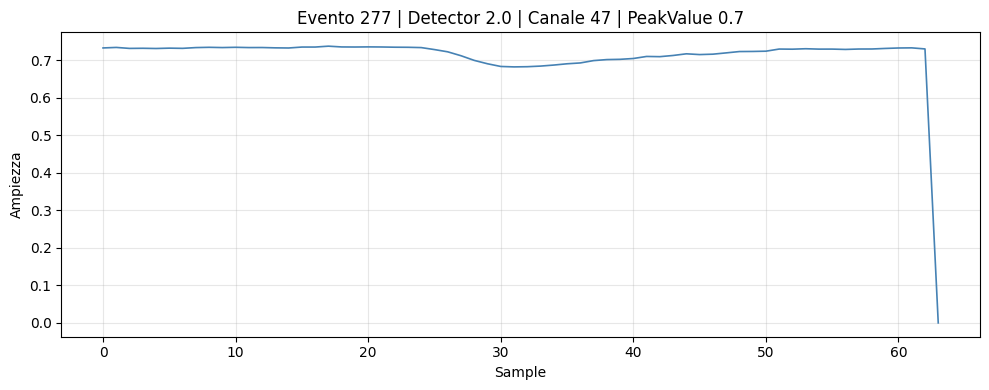

In [ ]:
#singola waveform esempio
import matplotlib.pyplot as plt
import numpy as np

def plot_waveform(df, idx, colonna_tempo=None):
    """
    idx = indice della riga nel DataFrame (non event_idx!)
    """
    riga = df.iloc[idx]
    wf = riga['Waveform']
    
    x = np.arange(len(wf)) if colonna_tempo is None else colonna_tempo
    
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(x, wf, color='steelblue', lw=1.2)
    ax.set_xlabel("Sample")
    ax.set_ylabel("Ampiezza")
    ax.set_title(
        f"Evento {riga['event_idx']} | "
        f"Detector {riga['Detector']} | "
        f"Canale {riga['Channel']} | "
        f"PeakValue {riga['PeakValue']:.1f}"
    )
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Esempio: plotta la prima waveform
plot_waveform(df, idx=5)

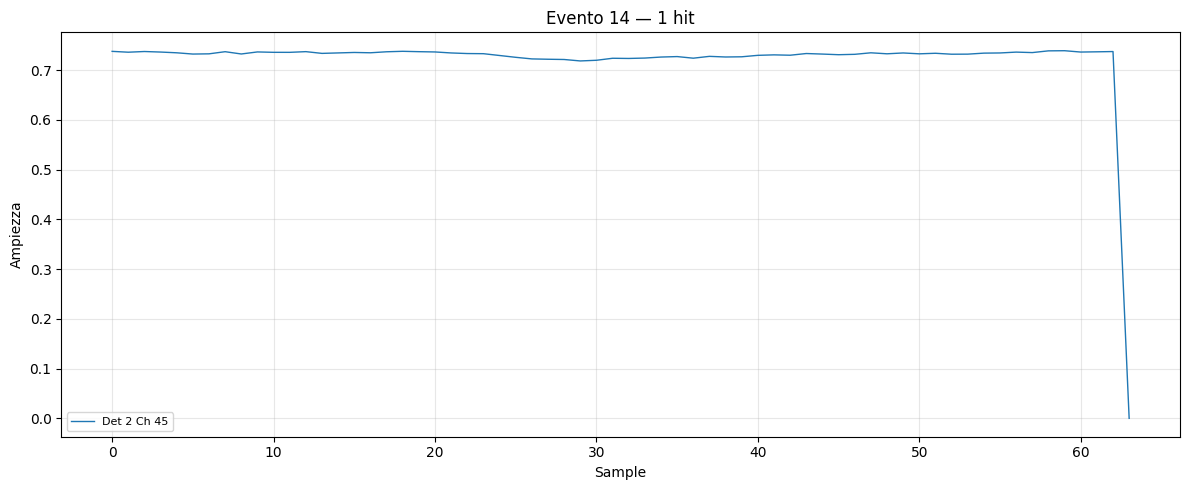

In [ ]:
#tutte waveform per evento
def plot_evento(df, event_idx):
    """Plotta tutte le hit di un evento sullo stesso grafico"""
    righe = df[df['event_idx'] == event_idx]
    
    fig, ax = plt.subplots(figsize=(12, 5))
    for _, riga in righe.iterrows():
        ax.plot(riga['Waveform'], lw=1, label=f"Det {int(riga['Detector'])} Ch {int(riga['Channel'])}")
    
    ax.set_xlabel("Sample")
    ax.set_ylabel("Ampiezza")
    ax.set_title(f"Evento {event_idx} — {len(righe)} hit")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Esempio
plot_evento(df, event_idx=df['event_idx'].iloc[0])

In [ ]:
#sample corrotto 
# Rimuove il sample 63 da ogni waveform
df['Waveform'] = df['Waveform'].apply(lambda wf: np.delete(wf, 63))

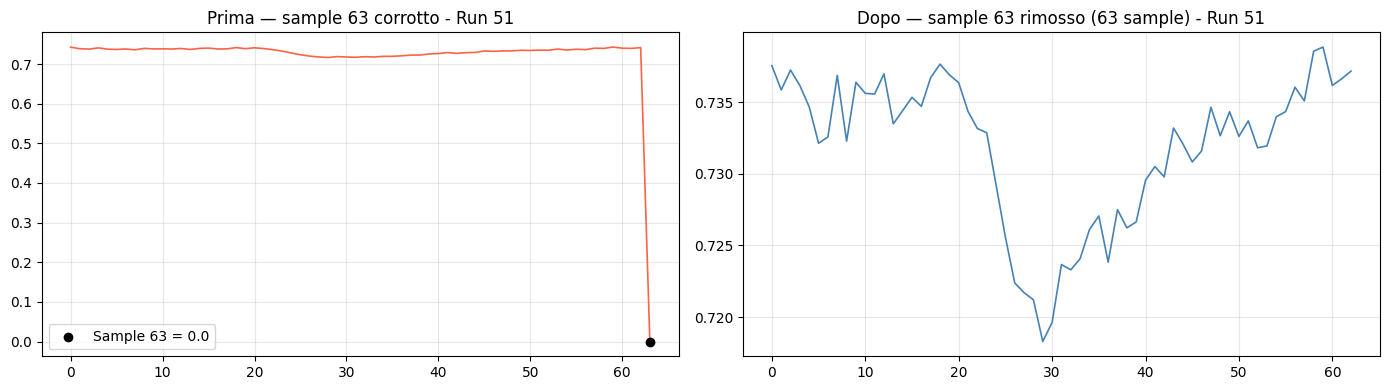

In [ ]:
# Rileggiti la waveform originale dal file per il confronto
with uproot.open(f"~/Scrivania/sampic_run{run_number}_merged.root") as file:
    tree = file["picoTree"]
    wf_originale = tree['Waveform'].array(library="np", entry_start=0, entry_stop=1)[0][0]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# --- Prima: waveform originale con sample 63 evidenziato ---
axes[0].plot(wf_originale, color='tomato', lw=1.2)
axes[0].scatter(63, wf_originale[63], color='black', zorder=5, label=f'Sample 63 = {wf_originale[63]:.1f}')
axes[0].set_title(f"Prima — sample 63 corrotto - Run {run_number}")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# --- Dopo: waveform pulita (sample 63 rimosso, ora ha n-1 punti) ---
wf_pulita = df['Waveform'].iloc[0]
axes[1].plot(wf_pulita, color='steelblue', lw=1.2)
axes[1].set_title(f"Dopo — sample 63 rimosso ({len(wf_pulita)} sample) - Run {run_number}")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



   event_idx  Channel  Detector  integrale  ampiezza  rise_time  fwhm
0         14       45       2.0  -0.209564 -0.016877        NaN  10.0
1        208       45       2.0  -0.444536 -0.024807       13.0  17.0
2        228       45       2.0  -0.950216 -0.055978        4.0  16.0
3        277       45       2.0  -0.629556 -0.044075        5.0  13.0
4        277       46       2.0  -0.372658 -0.023196        4.0  15.0
5        277       47       2.0  -0.713153 -0.050441        4.0  13.0
6        287       45       2.0  -0.389550 -0.023379       16.0  13.0
7        346       45       2.0  -0.436549 -0.029739        4.0  14.0
8        419       45       2.0  -0.828405 -0.053308        4.0  15.0
9        427       45       2.0  -0.610608 -0.038738        6.0  15.0


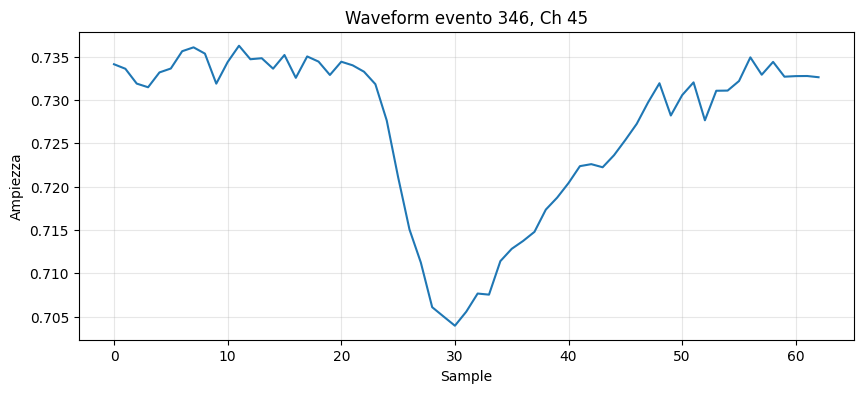

Min: 0.7039383
Max: 0.7362556
Media primi 10 sample (baseline): 0.73367715


In [ ]:
def analizza_waveform(wf, n_baseline=10):
    """
    n_baseline = quante sample iniziali usare per stimare la baseline
    """
    baseline = np.mean(wf[:n_baseline])
    wf_corr  = wf - baseline  # segnale centrato a zero

    # --- Picco (minimo perché segnale negativo) ---
    idx_picco = np.argmin(wf_corr)
    ampiezza  = np.min(wf_corr)  # valore negativo

    # --- Integrale (carica) ---
    integrale = np.trapezoid(wf_corr)  # sarà negativo

    # --- Tempo di salita (10% → 90% del picco, andando verso il basso) ---
    soglia_10 = 0.10 * ampiezza  # es. -10% del minimo
    soglia_90 = 0.90 * ampiezza  # es. -90% del minimo
    try:
        t10 = np.where(wf_corr[:idx_picco] <= soglia_10)[0][0]
        t90 = np.where(wf_corr[:idx_picco] <= soglia_90)[0][0]
        rise_time = t90 - t10
    except IndexError:
        rise_time = np.nan

    # --- FWHM ---
    soglia_half = 0.50 * ampiezza
    try:
        t_left  = np.where(wf_corr[:idx_picco] <= soglia_half)[0][0]
        t_right = idx_picco + np.where(wf_corr[idx_picco:] >= soglia_half)[0][0]
        fwhm = t_right - t_left
    except IndexError:
        fwhm = np.nan

    return {
        'baseline'  : baseline,
        'integrale' : integrale,
        'ampiezza'  : ampiezza,
        'idx_picco' : idx_picco,
        'rise_time' : rise_time,
        'fwhm'      : fwhm,
    }

# Applica a tutto il DataFrame
features = df['Waveform'].apply(analizza_waveform)
df_feat  = pd.DataFrame(features.tolist())
df       = pd.concat([df.reset_index(drop=True), df_feat], axis=1)

print(df[['event_idx', 'Channel', 'Detector', 'integrale', 'ampiezza', 'rise_time', 'fwhm']].head(10))

plt.figure(figsize=(10,4))
plt.plot(df['Waveform'].iloc[7])  # uso iloc[7] che ha ampiezza più grande
plt.grid(True, alpha=0.3)
plt.ylabel("Ampiezza")
plt.xlabel("Sample")
plt.title(f"Waveform evento {df['event_idx'].iloc[7]}, Ch {int(df['Channel'].iloc[7])}")
plt.show()

print("Min:", df['Waveform'].iloc[7].min())
print("Max:", df['Waveform'].iloc[7].max())
print("Media primi 10 sample (baseline):", df['Waveform'].iloc[7][:10].mean())

In [ ]:
#pile up

from scipy.signal import find_peaks

def is_pileup(wf, n_baseline=10, soglia_relativa=0.3):
    """
    Inverte il segnale per find_peaks (che cerca massimi)
    soglia_relativa: abbassala se non trova pile-up, alzala se ne trova troppi
    """
    baseline = np.mean(wf[:n_baseline])
    wf_corr  = -(wf - baseline)  # inverti: i minimi diventano massimi

    ampiezza_max = np.max(wf_corr)
    soglia       = soglia_relativa * ampiezza_max

    picchi, _ = find_peaks(wf_corr, height=soglia, distance=10)

    return len(picchi) > 1, len(picchi)

risultati      = df['Waveform'].apply(lambda wf: is_pileup(wf, soglia_relativa=0.3))
df['is_pileup'] = [r[0] for r in risultati]
df['n_picchi']  = [r[1] for r in risultati]

df_buoni  = df[~df['is_pileup']].reset_index(drop=True)
df_pileup = df[ df['is_pileup']].reset_index(drop=True)

print(f"✅ Eventi buoni : {len(df_buoni)}")
print(f"⚠️  Pile-up     : {len(df_pileup)}")
print(f"📊 Frazione pile-up: {len(df_pileup)/len(df)*100:.1f}%")

✅ Eventi buoni : 37391
⚠️  Pile-up     : 25553
📊 Frazione pile-up: 40.6%


/tmp/ipykernel_22507/3795906869.py:25: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/riccardo-speziali/progetti_python/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


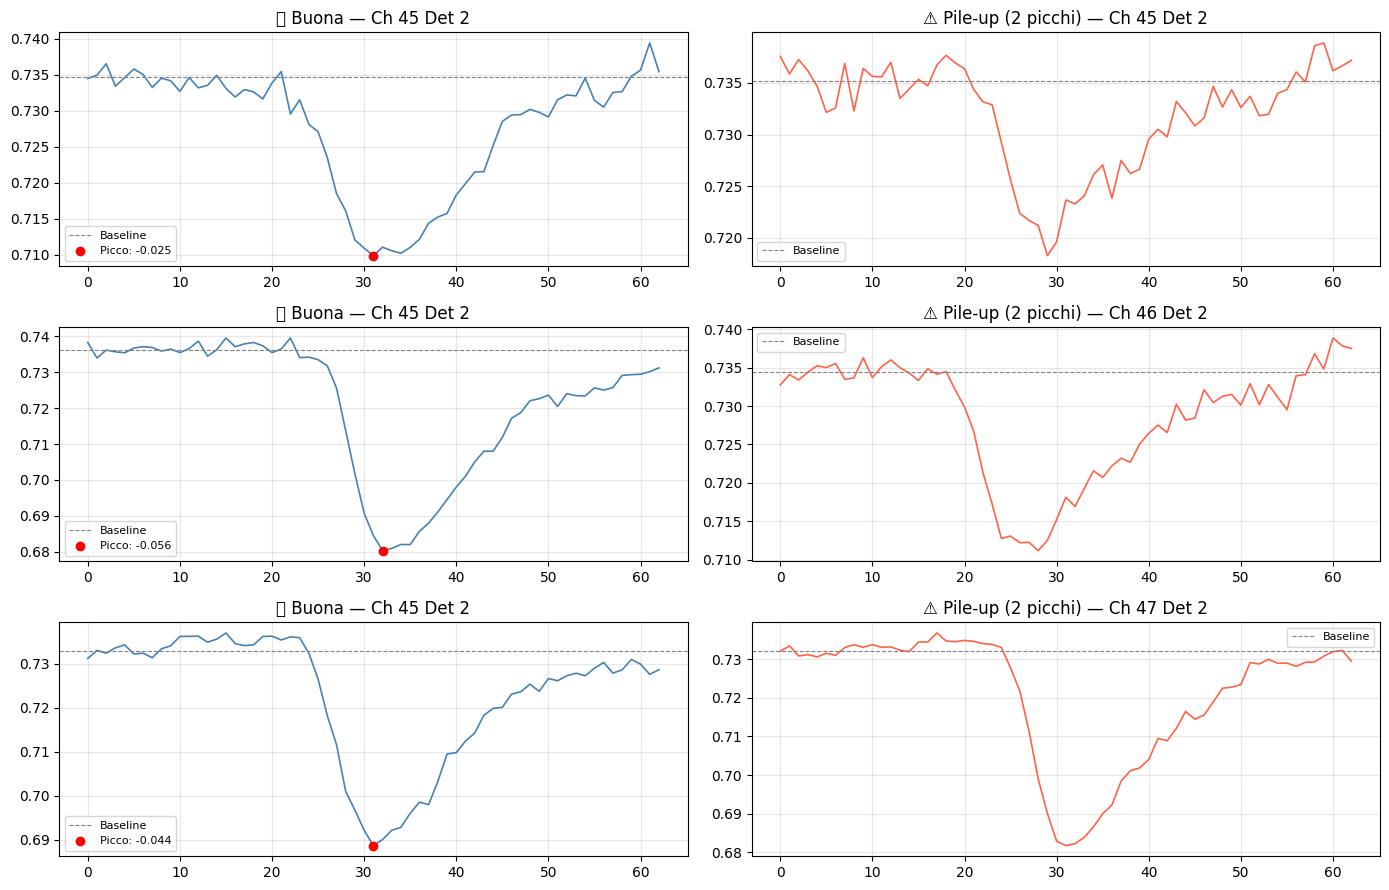

In [ ]:
def plot_confronto(df_buoni, df_pileup, n=3):
    fig, axes = plt.subplots(n, 2, figsize=(14, 3*n))

    for row in range(n):
        # --- Buona ---
        riga_b = df_buoni.iloc[row]
        wf_b   = riga_b['Waveform']
        axes[row, 0].plot(wf_b, color='steelblue', lw=1.2)
        axes[row, 0].axhline(float(riga_b['baseline']), color='gray', linestyle='--', lw=0.8, label='Baseline')
        axes[row, 0].scatter(int(riga_b['idx_picco']), wf_b[int(riga_b['idx_picco'])],
                             color='red', zorder=5, label=f"Picco: {float(riga_b['ampiezza']):.3f}")
        axes[row, 0].set_title(f"✅ Buona — Ch {int(riga_b['Channel'])} Det {int(riga_b['Detector'])}")
        axes[row, 0].legend(fontsize=8)
        axes[row, 0].grid(True, alpha=0.3)

        # --- Pile-up ---
        riga_p = df_pileup.iloc[row]
        wf_p   = riga_p['Waveform']
        axes[row, 1].plot(wf_p, color='tomato', lw=1.2)
        axes[row, 1].axhline(float(riga_p['baseline']), color='gray', linestyle='--', lw=0.8, label='Baseline')
        axes[row, 1].set_title(f"⚠️ Pile-up ({int(riga_p['n_picchi'])} picchi) — Ch {int(riga_p['Channel'])} Det {int(riga_p['Detector'])}")
        axes[row, 1].legend(fontsize=8)
        axes[row, 1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

plot_confronto(df_buoni, df_pileup, n=10)

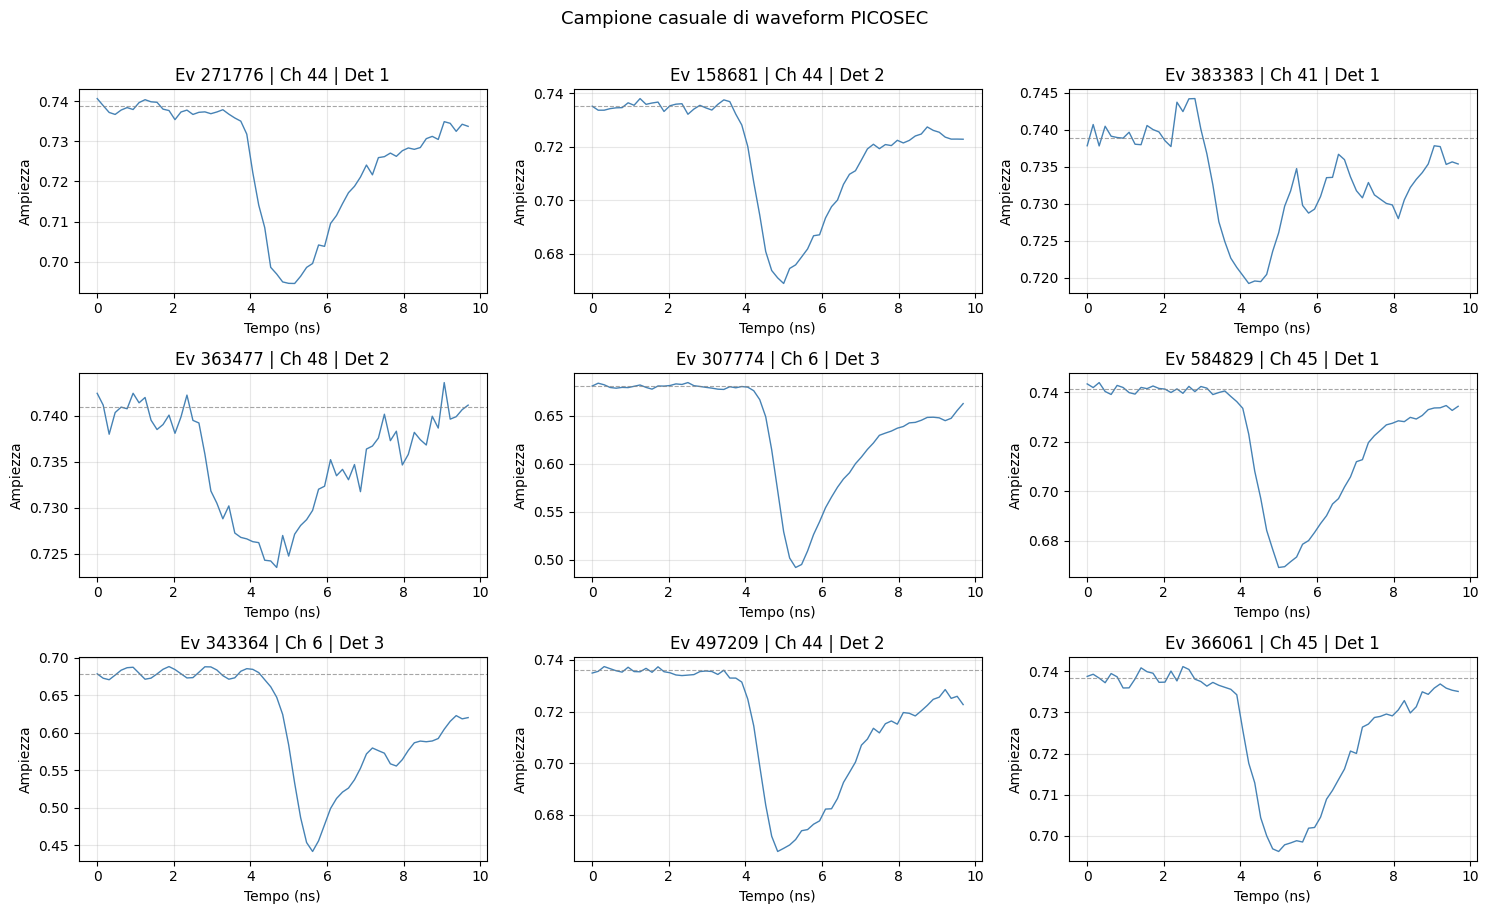

In [ ]:
# algoritmo per pile up custom made
import matplotlib.pyplot as plt
import numpy as np

# Plotta 9 waveform a caso per farsi un'idea visiva
fig, axes = plt.subplots(3, 3, figsize=(15, 9))

# Campiona 9 righe casuali
sample = df.sample(9, random_state=42).reset_index(drop=True)

for idx, ax in enumerate(axes.flat):
    riga = sample.iloc[idx]
    wf   = riga['Waveform']
    t_ns = np.arange(len(wf)) * (1/6.4)  # converti sample → ns
    
    ax.plot(t_ns, wf, color='steelblue', lw=1)
    ax.axhline(float(riga['baseline']), color='gray', linestyle='--', lw=0.8, alpha=0.7)
    ax.set_xlabel("Tempo (ns)")
    ax.set_ylabel("Ampiezza")
    ax.set_title(f"Ev {int(riga['event_idx'])} | Ch {int(riga['Channel'])} | Det {int(riga['Detector'])}")
    ax.grid(True, alpha=0.3)

plt.suptitle("Campione casuale di waveform PICOSEC", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

In [ ]:
from scipy.signal import find_peaks
from scipy.ndimage import uniform_filter1d

def is_pileup_picosec(wf, n_baseline=10, soglia_relativa=0.3, 
                       distance_samples=5, flat_top_samples=6):
    """
    Identifica pile-up in PICOSEC Micromegas con due criteri:
    
    1. DUE PICCHI VICINI: due minimi separati da almeno distance_samples
       (default=5 sample = ~780 ps a 6.4 GSa/s)
    
    2. FLAT TOP (massimo che persiste): la derivata vicino al picco 
       rimane quasi zero per più di flat_top_samples campioni
    
    Parametri:
    - soglia_relativa  : frazione dell'ampiezza per considerare un picco reale (default 0.3)
    - distance_samples : distanza minima tra due picchi in sample (default 5 ~ 780 ps)
    - flat_top_samples : quanti sample consecutivi vicino al picco per dire che è piatto
    """
    
    baseline = np.mean(wf[:n_baseline])
    wf_corr  = -(wf - baseline)  # inverti: minimi → massimi
    
    ampiezza_max = np.max(wf_corr)
    soglia       = soglia_relativa * ampiezza_max

    # --- Criterio 1: due picchi vicini ---
    picchi, props = find_peaks(wf_corr, height=soglia, distance=distance_samples)
    due_picchi = len(picchi) > 4

    # --- Criterio 2: flat top (picco che persiste) ---
    # Guarda la derivata nell'intorno del picco principale
    idx_picco  = np.argmax(wf_corr)
    
    # Finestra intorno al picco: ±flat_top_samples
    i_start = max(0, idx_picco - flat_top_samples)
    i_stop  = min(len(wf_corr), idx_picco + flat_top_samples)


    #prova di riccardo
    i_start =0
    i_stop = len(wf_corr)
    
    derivata  = np.abs(np.diff(wf_corr[i_start:i_stop]))
    soglia_dt = 0.05 * ampiezza_max  # derivata "piatta" = varia meno del 5% dell'ampiezza
    flat_top  = np.sum(derivata < soglia_dt) >= flat_top_samples

    pileup = due_picchi or flat_top

    return {
        'is_pileup'   : pileup,
        'due_picchi'  : due_picchi,
        'flat_top'    : flat_top,
        'n_picchi'    : len(picchi),
    }

# --- Applica a tutto il DataFrame ---
risultati = df['Waveform'].apply(is_pileup_picosec)
df['is_pileup']  = [r['is_pileup']  for r in risultati]
df['due_picchi'] = [r['due_picchi'] for r in risultati]
df['flat_top']   = [r['flat_top']   for r in risultati]
df['n_picchi']   = [r['n_picchi']   for r in risultati]

df_buoni  = df[~df['is_pileup']].reset_index(drop=True)
df_pileup = df[ df['is_pileup']].reset_index(drop=True)

# Quanti pile-up per ciascun criterio
n_due_picchi = df['due_picchi'].sum()
n_flat_top   = df['flat_top'].sum()

print(f"✅ Eventi buoni       : {len(df_buoni)}")
print(f"⚠️  Pile-up totali    : {len(df_pileup)}")
print(f"   di cui due picchi : {n_due_picchi}")
print(f"   di cui flat top   : {n_flat_top}")
print(f"📊 Frazione pile-up  : {len(df_pileup)/len(df)*100:.1f}%")

✅ Eventi buoni       : 268
⚠️  Pile-up totali    : 62676
   di cui due picchi : 1631
   di cui flat top   : 62225
📊 Frazione pile-up  : 99.6%


/tmp/ipykernel_22507/1440392335.py:31: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/riccardo-speziali/progetti_python/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


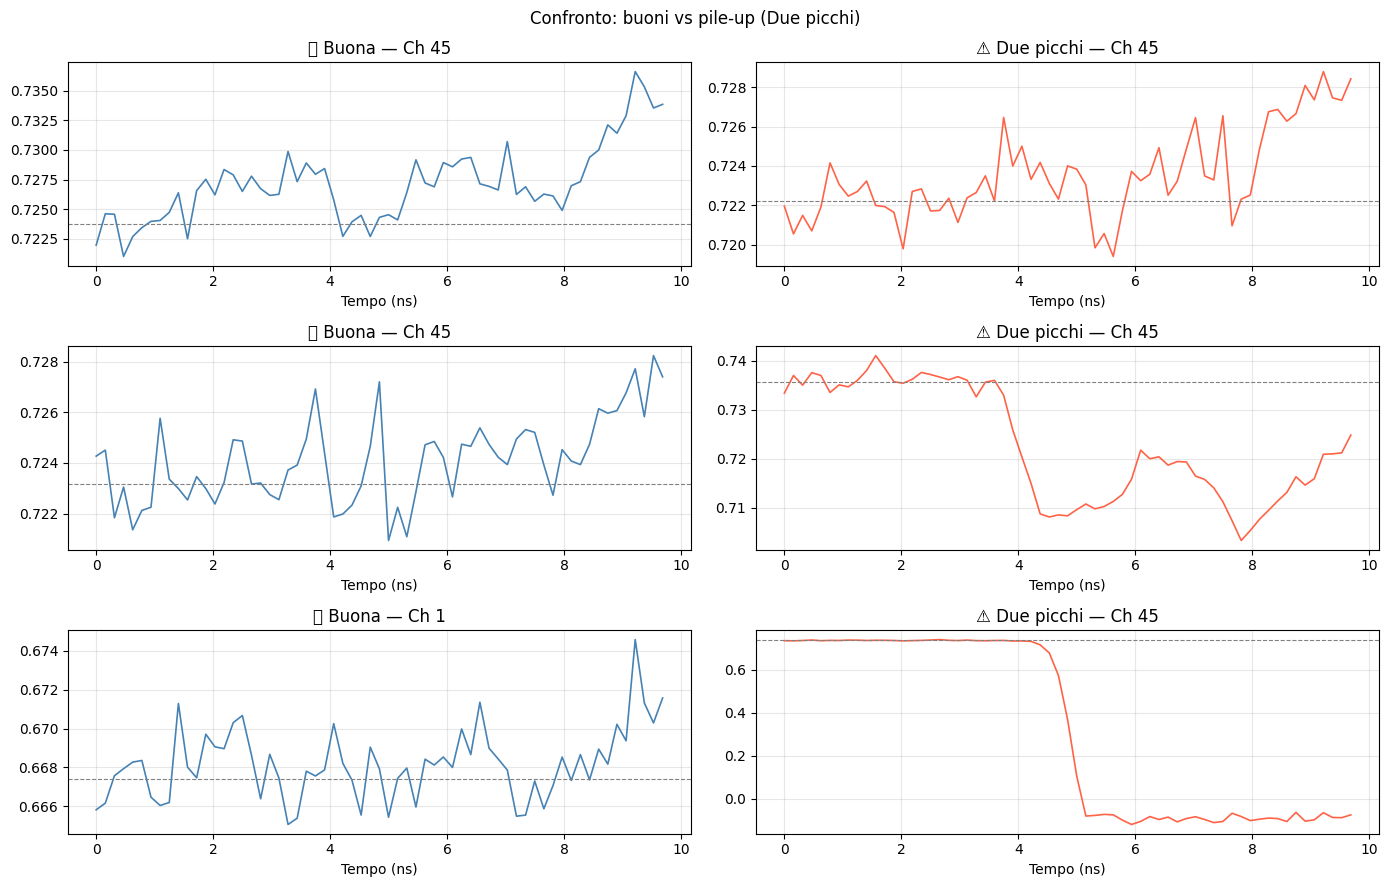

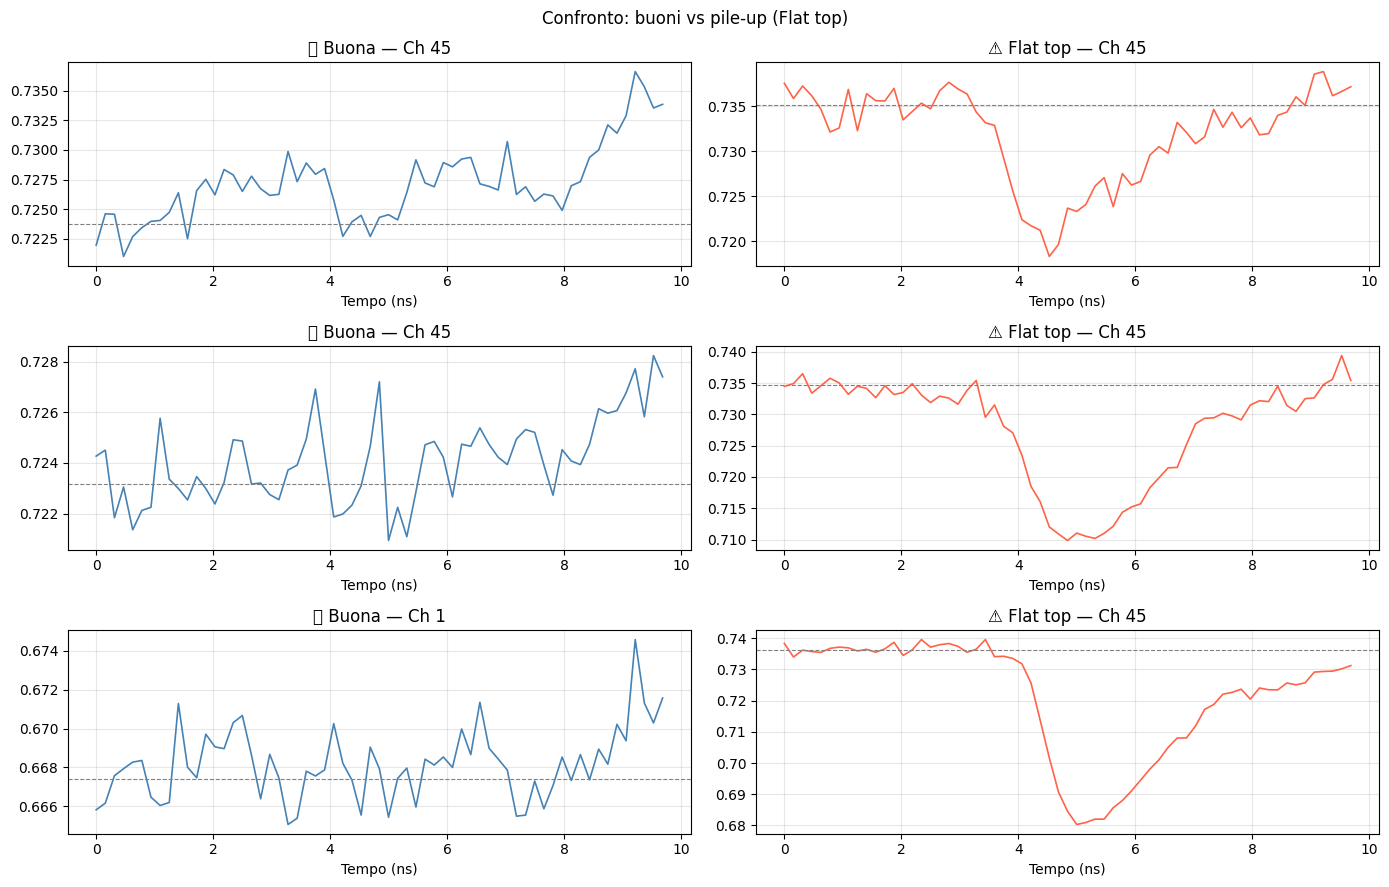

In [ ]:
def plot_pileup_tipo(df_buoni, df_pileup, tipo='due_picchi', n=3):
    """
    tipo = 'due_picchi' o 'flat_top'
    """
    df_tipo = df_pileup[df_pileup[tipo]].reset_index(drop=True)
    
    fig, axes = plt.subplots(n, 2, figsize=(14, 3*n))
    label = "Due picchi" if tipo == 'due_picchi' else "Flat top"

    for row in range(min(n, len(df_tipo))):
        t_ns = np.arange(len(df_buoni.iloc[row]['Waveform'])) * (1/6.4)

        # Buona
        riga_b = df_buoni.iloc[row]
        axes[row, 0].plot(t_ns, riga_b['Waveform'], color='steelblue', lw=1.2)
        axes[row, 0].axhline(float(riga_b['baseline']), color='gray', linestyle='--', lw=0.8)
        axes[row, 0].set_title(f"✅ Buona — Ch {int(riga_b['Channel'])}")
        axes[row, 0].set_xlabel("Tempo (ns)")
        axes[row, 0].grid(True, alpha=0.3)

        # Pile-up del tipo scelto
        riga_p = df_tipo.iloc[row]
        t_ns_p = np.arange(len(riga_p['Waveform'])) * (1/6.4)
        axes[row, 1].plot(t_ns_p, riga_p['Waveform'], color='tomato', lw=1.2)
        axes[row, 1].axhline(float(riga_p['baseline']), color='gray', linestyle='--', lw=0.8)
        axes[row, 1].set_title(f"⚠️ {label} — Ch {int(riga_p['Channel'])}")
        axes[row, 1].set_xlabel("Tempo (ns)")
        axes[row, 1].grid(True, alpha=0.3)

    plt.suptitle(f"Confronto: buoni vs pile-up ({label})", fontsize=12)
    plt.tight_layout()
    plt.show()

# Visualizza i due tipi separatamente
plot_pileup_tipo(df_buoni, df_pileup, tipo='due_picchi', n=3)
plot_pileup_tipo(df_buoni, df_pileup, tipo='flat_top',   n=3)

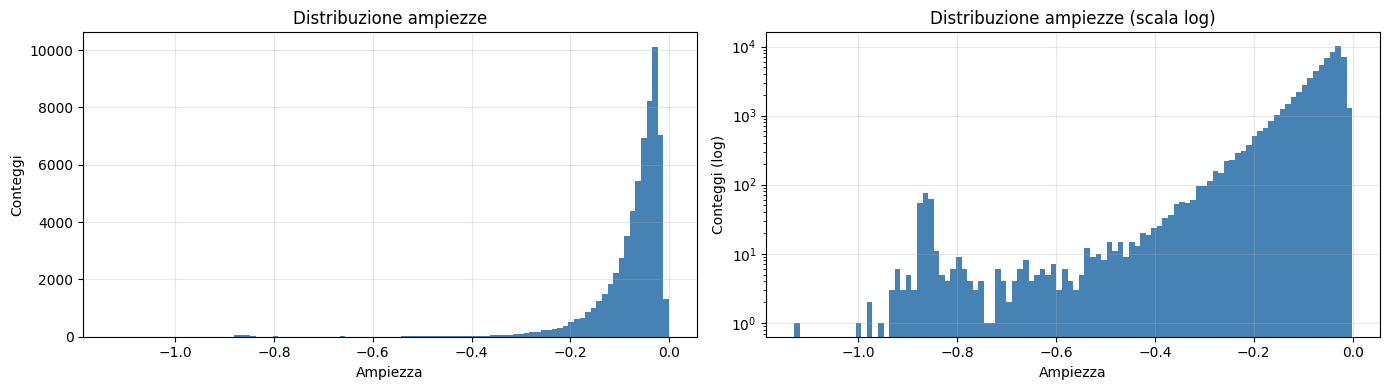

Min ampiezza : -1.1295
Max ampiezza : -0.0009
Media        : -0.0759
Mediana      : -0.0536
Percentile 90: -0.0213
Percentile 95: -0.0173
Percentile 99: -0.0036


In [ ]:
#analisi ampiezze segnale

import matplotlib.pyplot as plt
import numpy as np

# Distribuzione delle ampiezze (già calcolate nella cella 3)
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# --- Istogramma lineare ---
axes[0].hist(df['ampiezza'], bins=100, color='steelblue', edgecolor='none')
axes[0].set_xlabel("Ampiezza")
axes[0].set_ylabel("Conteggi")
axes[0].set_title("Distribuzione ampiezze")
axes[0].grid(True, alpha=0.3)

# --- Istogramma logaritmico (per vedere la coda) ---
axes[1].hist(df['ampiezza'], bins=100, color='steelblue', edgecolor='none')
axes[1].set_xlabel("Ampiezza")
axes[1].set_ylabel("Conteggi (log)")
axes[1].set_yscale('log')
axes[1].set_title("Distribuzione ampiezze (scala log)")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Statistiche base
print(f"Min ampiezza : {df['ampiezza'].min():.4f}")
print(f"Max ampiezza : {df['ampiezza'].max():.4f}")
print(f"Media        : {df['ampiezza'].mean():.4f}")
print(f"Mediana      : {df['ampiezza'].median():.4f}")
print(f"Percentile 90: {df['ampiezza'].quantile(0.90):.4f}")
print(f"Percentile 95: {df['ampiezza'].quantile(0.95):.4f}")
print(f"Percentile 99: {df['ampiezza'].quantile(0.99):.4f}")

Ampiezza bassa (> -0.02): 5219 eventi
Ampiezza alta  (≤ -0.02): 57725 eventi


/tmp/ipykernel_22507/758910520.py:36: UserWarning: Glyph 128309 (\N{LARGE BLUE CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_22507/758910520.py:36: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/riccardo-speziali/progetti_python/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128309 (\N{LARGE BLUE CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/riccardo-speziali/progetti_python/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


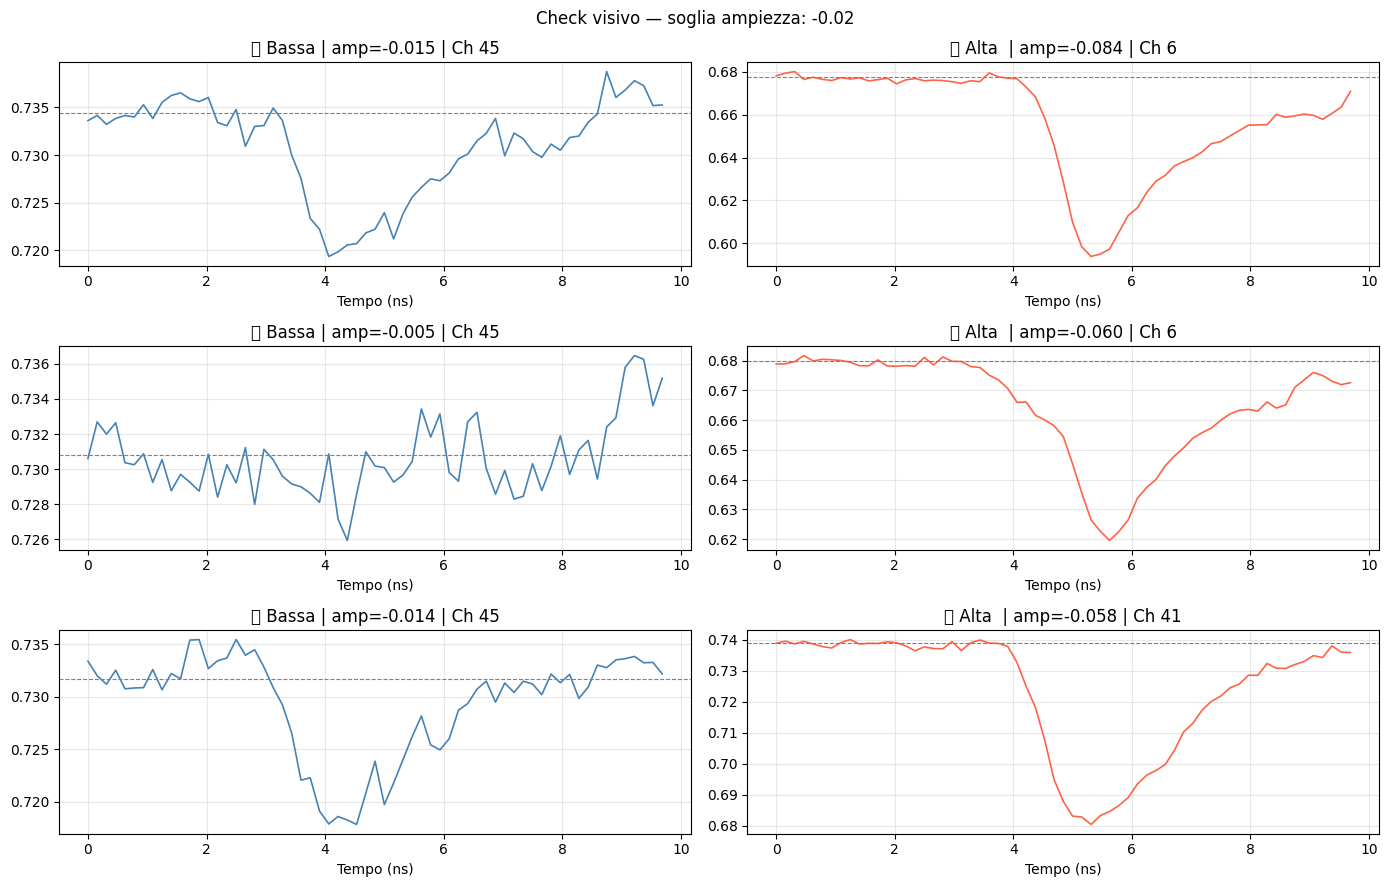

In [ ]:
# ── Cella 8 ── Scegli soglia e check visivo ────────────────────────────────────

# ⬇️ CAMBIA QUESTO dopo aver visto l'istogramma
SOGLIA_AMPIEZZA = -0.02  # es. -0.10 divide bassa da alta ampiezza

df_bassa = df[df['ampiezza'] > SOGLIA_AMPIEZZA].reset_index(drop=True)  # meno negativi = segnale piccolo
df_alta  = df[df['ampiezza'] <= SOGLIA_AMPIEZZA].reset_index(drop=True) # più negativi = segnale grande

print(f"Ampiezza bassa (> {SOGLIA_AMPIEZZA}): {len(df_bassa)} eventi")
print(f"Ampiezza alta  (≤ {SOGLIA_AMPIEZZA}): {len(df_alta)} eventi")

# --- Check visivo: 3 waveform per categoria ---
n = 3
fig, axes = plt.subplots(n, 2, figsize=(14, 3*n))

for row in range(n):
    # Bassa ampiezza
    riga_b = df_bassa.sample(1).iloc[0]
    t_ns   = np.arange(len(riga_b['Waveform'])) * (1/6.4)
    axes[row, 0].plot(t_ns, riga_b['Waveform'], color='steelblue', lw=1.2)
    axes[row, 0].axhline(float(riga_b['baseline']), color='gray', linestyle='--', lw=0.8)
    axes[row, 0].set_title(f"🔵 Bassa | amp={float(riga_b['ampiezza']):.3f} | Ch {int(riga_b['Channel'])}")
    axes[row, 0].set_xlabel("Tempo (ns)")
    axes[row, 0].grid(True, alpha=0.3)

    # Alta ampiezza
    riga_a = df_alta.sample(1).iloc[0]
    t_ns   = np.arange(len(riga_a['Waveform'])) * (1/6.4)
    axes[row, 1].plot(t_ns, riga_a['Waveform'], color='tomato', lw=1.2)
    axes[row, 1].axhline(float(riga_a['baseline']), color='gray', linestyle='--', lw=0.8)
    axes[row, 1].set_title(f"🔴 Alta  | amp={float(riga_a['ampiezza']):.3f} | Ch {int(riga_a['Channel'])}")
    axes[row, 1].set_xlabel("Tempo (ns)")
    axes[row, 1].grid(True, alpha=0.3)

plt.suptitle(f"Check visivo — soglia ampiezza: {SOGLIA_AMPIEZZA}", fontsize=12)
plt.tight_layout()
plt.show()